## Background

Fintech lenders make decisions about loan limits and client risk using data that already sits in their systems, but this data is rarely used to its full potential. In Kenya alone, 252 digital credit providers are now licensed by the Central Bank of Kenya, issuing over 8 million loans worth roughly KES 150 billion (about $1.16 billion) as of mid-2026 (Central Bank of Kenya, 2026). Loan amounts, balances, repayment history, arrears, and demographics are collected as a matter of course across this volume of lending, yet they are typically used only to process the single application in front of the officer, not to build a picture of the client over time.

This underuse is structural, not a data gap. CBK data shows default rates varying sharply by loan size - 83.1% on loans below KES 1,000, falling to 16.4% on loans above KES 50,000 (Central Bank of Kenya, 2025) - a pattern that reflects real behavioural differences between client segments, yet one that loan-by-loan, application-only scoring is not built to capture or act on. Decisioning systems assess risk at the point of application, fraud is caught only after losses occur, and records that could form a full client history are often scattered across separate origination, repayment, and collections systems. The consequences reach beyond individual lenders: the SME credit gap across Sub-Saharan Africa is estimated at $331 billion a year (International Finance Corporation, 2025), a gap that better use of data lenders already hold - rather than tighter across-the-board restriction - could help to narrow.

Where lenders elsewhere have addressed this, it has largely been through behavioural and alternative credit scoring, trained on a client's transaction and repayment history rather than static application fields, paired with anomaly detection that flags behaviour drifting from a client's own pattern; 90% of lenders surveyed globally say wider access to this kind of data would let them approve more creditworthy borrowers (Nova Credit, 2024). Even so, credit decisioning and fraud monitoring are usually still built as separate systems despite drawing on the same client record. The gap can be read through information asymmetry: a lender knows less about a borrower's true repayment behaviour than the borrower does, and loan-by-loan underwriting only partially closes that gap because each decision uses a narrow slice of data the lender already holds. Putting that existing history to fuller use, rather than collecting anything new, is the motivation for this project.

## Problem Statement

Fintech lenders assess client risk loan by loan rather than as a continuous behavioural picture, and detect fraud only after losses have already occurred rather than as it develops - even though the loan amounts, balances, repayment history, and arrears needed to do both differently already sit in their own systems. Financial DNA addresses both problems with a single, unified system built from a client's loan and repayment history: a behavioural profile that recommends a data-driven loan limit and continuously checks whether current activity still matches the client's own established pattern, replacing two blind spots with one shared, ongoing view of the client.

## Proposed Solution

## Import the data & Libraries

Importing the relevant libraries for this task.

In [318]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [319]:
df = pd.read_excel('Loan_approval.xlsx')

## Data Understanding

Checking the first five rows

In [320]:
df.head()

,Branch,Account Holder Name,Account ID,Approval Date,Activation Date,First Repayment Date,Last Payment Date,Product,Loan Amount,Principal Balance,...,Loan usage Business,Completed Loan Cycles (Client),Deposits Balance (Client),Locked Date,Arrears Tolerance Period,Original Account ID,Disbursed Amount,Environmental & Social Risk,Age Band (Client),Nature of business
0,Branch-002,NaN,ACC-8413677F5127,2025-01-05,2025-01-05,2025-02-04,2026-09-27,Product-044,174800,167700,...,BusinessPurpose-007,0,0,NaT,30,NaN,174800,Medium,30-39,Chemist
1,Branch-008,NaN,ACC-02AAD5CBBFD3,2017-05-08,2017-05-08,2017-05-19,2026-09-16,Product-026,3060000,2716200,...,NaN,0,0,NaT,5,NaN,3060000,Medium,30-39,NaN
2,Branch-068,NaN,ACC-C3EA6CE82D4F,2017-07-29,2017-07-28,2017-09-22,2026-05-17,Product-026,4560000,3881300,...,NaN,1,0,NaT,5,NaN,4560000,Medium,40-49,NaN
3,Branch-008,NaN,ACC-BC262E2C2C28,2017-01-13,2016-12-06,2017-01-03,2026-04-18,Product-026,1540000,269600,...,NaN,0,0,NaT,5,NaN,1540000,Medium,NaN,NaN
4,Branch-016,NaN,ACC-B479775F2524,2017-02-08,2017-01-03,2017-01-31,2026-06-15,Product-026,1480000,526100,...,NaN,0,0,NaT,5,NaN,1480000,Medium,NaN,NaN


Checking the last 5 rows

In [321]:
df.tail()

,Branch,Account Holder Name,Account ID,Approval Date,Activation Date,First Repayment Date,Last Payment Date,Product,Loan Amount,Principal Balance,...,Loan usage Business,Completed Loan Cycles (Client),Deposits Balance (Client),Locked Date,Arrears Tolerance Period,Original Account ID,Disbursed Amount,Environmental & Social Risk,Age Band (Client),Nature of business
23749,Branch-022,NaN,ACC-0352D31E8DF5,2026-07-05,2026-07-05,2026-08-08,2026-09-08,Product-093,5850000,6360700,...,BusinessPurpose-051,0,254300,NaT,3,NaN,6936900,Medium,30-39,Bars/ pubs and clubs / liquor stores
23750,Branch-072,NaN,ACC-5C5734B109E5,2026-06-19,2026-06-19,2026-07-19,2026-08-18,Product-044,1200000,1032800,...,BusinessPurpose-007,0,0,NaT,30,NaN,1200000,Low,20-29,NaN
23751,Branch-023,NaN,ACC-ACAC526857F7,2026-04-12,2026-04-12,2026-05-12,2026-06-30,Product-045,1486800,1339900,...,BusinessPurpose-036,0,1860800,NaT,3,NaN,1635500,Low,40-49,"traditional artefacts, honey and herbs"
23752,Branch-072,NaN,ACC-9C2B6FB9B440,2026-10-27,2026-10-27,2026-11-26,NaT,Product-044,1722700,1722700,...,BusinessPurpose-007,0,0,NaT,30,NaN,1722700,NaN,20-29,NaN
23753,Branch-022,NaN,ACC-C6191020DA44,2026-06-23,2026-06-23,2026-07-26,NaT,Product-048,466200,512800,...,BusinessPurpose-009,14,1693700,NaT,3,NaN,512800,NaN,20-29,Boutiques


Viewing general statistical columnal data for numeric columns

In [322]:
df.describe()

,Account Holder Name,Approval Date,Activation Date,First Repayment Date,Last Payment Date,Loan Amount,Principal Balance,Interest Balance,Fee Balance,Interest Accrued,...,Last Payment Amount,Expected Maturity Date,Days Late,Created (Client),Interest Rate,Completed Loan Cycles (Client),Deposits Balance (Client),Locked Date,Arrears Tolerance Period,Disbursed Amount
count,0.0,23754,23754,23754,22025,2.375400e+04,2.375400e+04,2.375400e+04,2.375400e+04,2.375400e+04,...,2.375400e+04,23754,23754.000000,23754,23754.000000,23754.000000,2.375400e+04,644,23754.000000,2.375400e+04
mean,NaN,2025-01-04 00:18:33.008335360,2025-01-10 13:29:21.353877504,2025-02-10 10:58:13.609497600,2026-07-30 08:43:26.056753920,3.257708e+06,2.735155e+06,6.643980e+04,1.655995e+04,5.405495e+04,...,1.693383e+05,2029-09-07 12:36:00.545592320,47.785720,2022-06-26 20:49:17.110381312,7.052780,1.746906,1.016961e+05,2026-02-27 23:55:31.677018624,22.129410,3.492660e+06
min,NaN,2012-07-07 00:00:00,2012-07-07 00:00:00,2012-07-28 00:00:00,2024-06-21 00:00:00,5.000000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2015-07-28 00:00:00,0.000000,2010-07-15 00:00:00,0.000000,0.000000,0.000000e+00,2022-03-11 00:00:00,0.000000,5.000000e+03
25%,NaN,2024-04-28 06:00:00,2024-04-29 00:00:00,2024-05-29 06:00:00,2026-06-17 00:00:00,1.000000e+06,7.148000e+05,0.000000e+00,0.000000e+00,5.400000e+03,...,1.980000e+04,2027-05-06 00:00:00,0.000000,2020-04-22 00:00:00,3.500000,0.000000,0.000000e+00,2025-12-28 00:00:00,5.000000,1.048800e+06
50%,NaN,2025-09-06 00:00:00,2025-09-21 00:00:00,2025-10-21 00:00:00,2026-08-02 00:00:00,2.082000e+06,1.708850e+06,0.000000e+00,0.000000e+00,2.060000e+04,...,7.850000e+04,2029-03-09 00:00:00,0.000000,2024-04-08 00:00:00,3.500000,1.000000,0.000000e+00,2026-03-22 00:00:00,30.000000,2.236000e+06
75%,NaN,2026-04-04 00:00:00,2026-04-11 00:00:00,2026-05-12 00:00:00,2026-09-17 00:00:00,4.470000e+06,3.671875e+06,2.160000e+04,2.000000e+02,6.010000e+04,...,1.810000e+05,2031-12-22 00:00:00,9.000000,2025-10-06 00:00:00,3.500000,2.000000,2.567500e+04,2026-06-06 00:00:00,30.000000,4.673450e+06
max,NaN,2026-11-16 00:00:00,2026-11-16 00:00:00,2026-12-16 00:00:00,2026-11-17 00:00:00,4.000000e+07,4.612400e+07,1.418350e+07,1.852950e+07,6.383200e+06,...,1.758160e+07,2034-10-06 00:00:00,4828.000000,2026-11-15 00:00:00,92.470000,40.000000,3.184120e+07,2026-11-08 00:00:00,30.000000,4.612400e+07
std,NaN,NaN,NaN,NaN,NaN,3.542596e+06,3.172838e+06,4.091752e+05,1.611298e+05,1.357705e+05,...,3.642956e+05,NaN,295.347223,NaN,13.441117,2.360336,5.495872e+05,NaN,11.879537,3.919352e+06


Checking for unique values, and the number of missing values columnally.

In [323]:
# Unique value counts per column
unique_counts = df.nunique().sort_values()

unique_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': unique_counts,
    'n_missing': df.isnull().sum(),
    'pct_unique': (unique_counts / len(df) * 100).round(2)
}).sort_values('n_unique')

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(unique_summary)

# Flag columns with only 1 unique value - zero variance, safe to drop
constant_cols = unique_summary[unique_summary['n_unique'] <= 1].index.tolist()
print(f"\nConstant / zero-variance columns ({len(constant_cols)}): {constant_cols}")

# Show the actual unique values for low-cardinality columns (likely categorical)
print("\nUnique values for low-cardinality columns (<=15 unique values):")
for col in unique_summary[unique_summary['n_unique'] <= 15].index:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].unique())

Dataset shape: 23754 rows, 49 columns



,dtype,n_unique,n_missing,pct_unique
Account Holder ID,float64,0,23754,0.00
Account Holder Name,float64,0,23754,0.00
Account Sub-State,object,1,23110,0.00
Was Rescheduled,object,1,0,0.00
Was Refinanced,object,2,0,0.01
Account State,object,2,0,0.01
Environmental & Social Risk,object,2,748,0.01
Gender (Client),object,2,0,0.01
Risk Level,object,6,0,0.03
Arrears Tolerance Period,int64,7,0,0.03



Constant / zero-variance columns (4): ['Account Holder ID', 'Account Holder Name', 'Account Sub-State', 'Was Rescheduled']

Unique values for low-cardinality columns (<=15 unique values):

Account Holder ID (0 unique):
[nan]

Account Holder Name (0 unique):
[nan]

Account Sub-State (1 unique):
[nan 'Locked']

Was Rescheduled (1 unique):
['No']

Was Refinanced (2 unique):
['No' 'Yes']

Account State (2 unique):
['Active' 'In Arrears']

Environmental & Social Risk (2 unique):
['Medium' 'Low' nan]

Gender (Client) (2 unique):
['Male' 'Female']

Risk Level (6 unique):
['Current ' '>180 Days' '91-180 Days' '1-30 days' '31-60 Days'
 '61-90 Days']

Arrears Tolerance Period (7 unique):
[30  5 15  3  0  7  4]

Loan Usage (8 unique):
['LoanPurpose-003' nan 'LoanPurpose-004' 'LoanPurpose-005'
 'LoanPurpose-007' 'LoanPurpose-001' 'LoanPurpose-006' 'LoanPurpose-002'
 'LoanPurpose-008']

Age Band (Client) (8 unique):
['30-39' '40-49' nan '20-29' '<18' '50-59' '60-69' '10-19' '70+']


**Identifiers**
- `Branch` - code for the branch holding the loan (75 branches)
- `Account ID` - unique identifier for the loan account (one per row)
- `Account Holder ID` - anonymized numeric ID for the client; repeats across a client's `Completed Loan Cycles`
- `Account Holder Name` - anonymized numeric placeholder, not a usable name field
- `Original Account ID` - account ID of the prior loan this one replaced, populated only for refinanced/rescheduled accounts (50 unique values)
- `Product` - loan product code (101 products)

**Dates (loan lifecycle)**
- `Approval Date`, `Activation Date` - when the loan was approved and disbursed
- `First Repayment Date`, `Last Payment Date` - start and most recent point of the repayment trail
- `Expected Maturity Date` - scheduled payoff date
- `Created (Client)` - when the client record was created
- `Locked Date` - when the account was locked (see `Account Sub-State`)

**Loan terms**
- `Loan Amount` - approved principal
- `Disbursed Amount` - amount actually released to the client (can differ from `Loan Amount`)
- `Interest Rate` - loan interest rate
- `Number of Installments` - length of the repayment schedule
- `Arrears Tolerance Period` - grace days before a missed payment counts as arrears

**Balances (current state of the account)**
- `Principal Balance`, `Interest Balance`, `Fee Balance`, `Interest Accrued`, `Penalty Balance` - outstanding balance by component
- `Total Balance` - sum of outstanding balances; **stored as inconsistently formatted text** (mixed comma/no-comma strings) and needs numeric conversion before use

**Due vs. paid (repayment performance)**
- `Principal Due`, `Interest Due`, `Fees Due`, `Penalty Due`, `Total Due` - currently owed
- `Principal Paid`, `Interest Paid`, `Fees Paid`, `Total Paid` - cumulative amounts paid
- `Last Payment Amount` - value of the most recent payment

**Arrears / risk**
- `Days In Arrears`, `Days Late` - lateness measures
- `Risk Level` - bucketed arrears category (Current, 1–30, 31–60, 61–90, 91–180, >180 days)
- `Account State` - Active / In Arrears
- `Account Sub-State` - constant "Locked" for every row; **zero variance, uninformative for modelling**
- `Was Refinanced` - Yes/No flag for refinanced loans
- `Was Rescheduled` - constant "No" for every row; **zero variance, uninformative for modelling**
- `Environmental & Social Risk` - Low/Medium ESG risk rating on the loan

**Client demographics**
- `Gender (Client)` - Male/Female
- `Age Band (Client)` - 10-year bands, `<18` to `70+`
- `Loan Usage` - loan purpose code (8 categories)
- `Loan usage Business`, `Nature of business` - business-purpose code and sector (e.g. chemist, bakery, agri-business) for business loans
- `Completed Loan Cycles (Client)` - number of prior loans this client has completed (repeat-borrower history)
- `Deposits Balance (Client)` - client's savings/deposit balance held at the institution

## Data Cleaning 

Before any feature engineering, we run a full missing-value audit across all 49 raw columns. The goal is to classify each column with missing data into one of three buckets - drop (unusable or redundant), impute (missing is small and a reasonable default exists), or engineer (the missingness itself is informative) - rather than applying one blanket strategy to the whole dataset.

In [324]:
missing =df.isna().sum()
print(missing)

Branch                                0
Account Holder Name               23754
Account ID                            0
Approval Date                         0
Activation Date                       0
First Repayment Date                  0
Last Payment Date                  1729
Product                               0
Loan Amount                           0
Principal Balance                     0
Interest Balance                      0
Fee Balance                           0
Interest Accrued                      0
Penalty Balance                       0
Days In Arrears                       0
Account Holder ID                 23754
Total Balance                     23387
Principal Due                         0
Interest Due                          0
Fees Due                              0
Penalty Due                           0
Total Due                             0
Principal Paid                        0
Interest Paid                         0
Fees Paid                             0


In [325]:
## check original ID missing values
print(df['Original Account ID'].dropna())

41       ACC-AEB8B58C5651
104      ACC-631DCEC79FB2
107      ACC-66A0B4364D6B
138      ACC-2304A3E1BF88
139      ACC-5B79E6717B4B
145      ACC-DCD334167AE1
185      ACC-9F33F69CD8AB
186      ACC-1A14C57CAFBE
192      ACC-30806A20F510
1772     ACC-D1A3F6D72B27
2150     ACC-D57FE9EDA355
2309     ACC-F22C83423E2A
3570     ACC-B678EBE11425
4101     ACC-117E3877D5C7
4897     ACC-7020F544E2DB
5341     ACC-095C70DF34BE
6595     ACC-75BBF6FB6031
6877     ACC-EDA4738718A5
7207     ACC-8D16EA6F3CBF
7737     ACC-F5DDDFB9C214
9368     ACC-A4F145E9CB01
9610     ACC-15632C0C03CC
11209    ACC-1BEB74ED98B7
11210    ACC-6B606F193857
11748    ACC-791054334C8D
12125    ACC-69376CB3628E
12784    ACC-940782B940CD
13305    ACC-B3FBEED0219A
14923    ACC-39AB9833590D
14971    ACC-311C6C069E57
14972    ACC-478694F7FE7A
14973    ACC-B01C4EC89411
16487    ACC-FFF208AB09C2
16560    ACC-2DB7566ED4FC
16752    ACC-A00EA6E31773
16892    ACC-978E66CC04F0
17069    ACC-037B50D0C3AD
17070    ACC-EB15325E30A9
17893    ACC

In [326]:
## checking if original account ID and account ID are the same
print(df[['Original Account ID', 'Account ID']].head(109))

    Original Account ID        Account ID
0                   NaN  ACC-8413677F5127
1                   NaN  ACC-02AAD5CBBFD3
2                   NaN  ACC-C3EA6CE82D4F
3                   NaN  ACC-BC262E2C2C28
4                   NaN  ACC-B479775F2524
..                  ...               ...
104    ACC-631DCEC79FB2  ACC-BFB26E3D0159
105                 NaN  ACC-604AAC053460
106                 NaN  ACC-7AF3E2704992
107    ACC-66A0B4364D6B  ACC-67E9AEAD42F3
108                 NaN  ACC-12D8F1DF9422

[109 rows x 2 columns]


In [327]:
## drop the column
df = df.drop(columns=['Original Account ID'], axis=1)

**`Original Account ID`** is populated in only 109 of 23,754 rows (~0.5%) - it links a refinanced/rescheduled loan back to the account it replaced. Cell 14 confirms it never duplicates `Account ID`, so it isn't a data-entry artifact, but at this coverage level it can't support any per-row feature, and the same information is already captured more usably by the `Was Refinanced` flag. We drop it rather than impute it, since there's no reasonable default for "which account this replaced."

In [328]:
## checking if drop worked
df.columns

Index(['Branch', 'Account Holder Name', 'Account ID', 'Approval Date',
       'Activation Date', 'First Repayment Date', 'Last Payment Date',
       'Product', 'Loan Amount', 'Principal Balance', 'Interest Balance',
       'Fee Balance', 'Interest Accrued', 'Penalty Balance', 'Days In Arrears',
       'Account Holder ID', 'Total Balance', 'Principal Due', 'Interest Due',
       'Fees Due', 'Penalty Due', 'Total Due', 'Principal Paid',
       'Interest Paid', 'Fees Paid', 'Total Paid', 'Number of Installments',
       'Account State', 'Account Sub-State', 'Last Payment Amount',
       'Expected Maturity Date', 'Gender (Client)', 'Loan Usage',
       'Was Refinanced', 'Was Rescheduled', 'Days Late', 'Risk Level',
       'Created (Client)', 'Interest Rate', 'Loan usage Business',
       'Completed Loan Cycles (Client)', 'Deposits Balance (Client)',
       'Locked Date', 'Arrears Tolerance Period', 'Disbursed Amount',
       'Environmental & Social Risk', 'Age Band (Client)',
       'Natur

In [329]:
## check total balance missing values
print(df['Total Balance'].dropna())

0          170,293.99
1        6,287,585.28
10         5501209.91
37       6,903,397.97
82         3709502.62
             ...     
23532    3,513,873.66
23575      294,355.98
23610      409,893.57
23615    3,577,678.04
23737    3,918,927.91
Name: Total Balance, Length: 367, dtype: object


**`Total Balance`** is missing in 23,387 of 23,754 rows (~98.5%) and, where present, is stored as inconsistently formatted text (some values comma-separated, some not - see cell 17), which would need cleaning even before imputation. Rather than impute a field that's missing for nearly the whole dataset, we drop the raw column and recompute it directly as `Principal Balance + Interest Balance + Fee Balance + Penalty Balance`, using columns that are complete for every row. This gives us a fully populated, numerically consistent balance figure instead of a mostly-empty one.

In [330]:
## total balance column
df = df.drop(columns=['Total Balance'])
df['Total Balance'] = (
    df['Principal Balance'] + df['Interest Balance']
    + df['Fee Balance'] + df['Penalty Balance']
)

**`Account Holder Name`** and **`Account Holder ID`** are both missing for all 23,754 rows (100%) - they were anonymized/stripped from this dataset entirely rather than partially withheld. With zero non-null values, there is nothing to impute or engineer from either column, so both are dropped outright.

In [331]:
df = df.drop(columns=['Account Holder Name'])
print(df.isna().sum())

Branch                                0
Account ID                            0
Approval Date                         0
Activation Date                       0
First Repayment Date                  0
Last Payment Date                  1729
Product                               0
Loan Amount                           0
Principal Balance                     0
Interest Balance                      0
Fee Balance                           0
Interest Accrued                      0
Penalty Balance                       0
Days In Arrears                       0
Account Holder ID                 23754
Principal Due                         0
Interest Due                          0
Fees Due                              0
Penalty Due                           0
Total Due                             0
Principal Paid                        0
Interest Paid                         0
Fees Paid                             0
Total Paid                            0
Number of Installments                0


In [332]:
print(df['Account Holder ID'].dropna())

Series([], Name: Account Holder ID, dtype: float64)


In [333]:
## drop account holder ID column
df = df.drop(columns=['Account Holder ID'])

In [334]:
## check if the missing values in 'Account Sub-State' and 'Locked Date' are the same
sub_null = df['Account Sub-State'].isna()
locked_null = df['Locked Date'].isna()
print((sub_null == locked_null).all()) 

True


In [335]:
df['Account Sub-State'] = df['Account Sub-State'].fillna('Active')

In [336]:
df = df.drop(columns=['Locked Date'])
df.isna().sum()

Branch                               0
Account ID                           0
Approval Date                        0
Activation Date                      0
First Repayment Date                 0
Last Payment Date                 1729
Product                              0
Loan Amount                          0
Principal Balance                    0
Interest Balance                     0
Fee Balance                          0
Interest Accrued                     0
Penalty Balance                      0
Days In Arrears                      0
Principal Due                        0
Interest Due                         0
Fees Due                             0
Penalty Due                          0
Total Due                            0
Principal Paid                       0
Interest Paid                        0
Fees Paid                            0
Total Paid                           0
Number of Installments               0
Account State                        0
Account Sub-State        

**`Account Sub-State`** only ever takes one observed value, `"Locked"` - it's populated exactly where **`Locked Date`** is populated and null everywhere else (confirmed in cell 22, where the two null-masks match exactly). That means missing here doesn't mean "unknown state," it means "never locked." We fill the nulls with `"Active"` to make that implicit second category explicit, then drop `Locked Date`: once the lock status is captured as a category, the specific date it happened on adds no further modelling value and is itself missing for the same ~93% of rows.

In [337]:
## handling last payment date missing values
df['Has Made Last Payment'] = df['Last Payment Date'].notna()
df.columns[-1]

'Has Made Last Payment'

**`Last Payment Date`** is missing for 1,729 of 23,754 rows (~7.3%) - these are accounts that have never received a payment, not accounts with unknown payment dates. Imputing a fake date would misrepresent that. Instead we engineer a boolean flag, `Has Made Last Payment` (`Last Payment Date.notna()`), which preserves the column as a usable feature and keeps `Last Payment Date` itself intact for the ~92.7% of accounts where it's real.

In [338]:
df['Nature of business'].value_counts()

Nature of business
Cooking gas and oil fuels                          2538
Bookshops                                          2056
Agri-business (dairy, meat, poultry, fish)         2012
Bakeries                                           1557
Chemist                                            1252
Agri-business (fruits)                              777
Bars/ pubs and clubs / liquor stores                757
Baby day care services                              421
Woodwork & timber                                   366
Boutiques                                           311
Auto spare parts                                    302
Firewood/ charcoa                                   245
Retail Shops                                        239
traditional artefacts, honey and herbs              221
Health care services                                213
Fuel stations                                       156
Leather & skin tanning                              143
Security services            

**`Nature of business`** is missing for roughly 46% of rows - this lines up with the loan book containing both business and non-business loans, so the null isn't a data-quality gap but a structural one: the field simply doesn't apply outside business loans. We fill it with `"Unknown"` rather than the mode, since assigning a real business category (e.g. "Bakeries") to a non-business loan would misrepresent the client, while `"Unknown"` keeps the row usable and the omission visible to any downstream model.

In [339]:
df['Nature of business'] = df['Nature of business'].fillna('Unknown')
df['Nature of business'].dropna(inplace=True)
df.isna().sum()

Branch                               0
Account ID                           0
Approval Date                        0
Activation Date                      0
First Repayment Date                 0
Last Payment Date                 1729
Product                              0
Loan Amount                          0
Principal Balance                    0
Interest Balance                     0
Fee Balance                          0
Interest Accrued                     0
Penalty Balance                      0
Days In Arrears                      0
Principal Due                        0
Interest Due                         0
Fees Due                             0
Penalty Due                          0
Total Due                            0
Principal Paid                       0
Interest Paid                        0
Fees Paid                            0
Total Paid                           0
Number of Installments               0
Account State                        0
Account Sub-State        

In [340]:
df['Age Band (Client)'].value_counts()

Age Band (Client)
30-39    9749
40-49    6156
50-59    4143
20-29    3368
60-69     213
<18        69
10-19       6
70+         3
Name: count, dtype: int64

**`Age Band (Client)`** is missing for only 47 of 23,754 rows (~0.2%), and one band (30–39) already accounts for ~41% of all clients. At this scale, mode imputation carries negligible risk of distorting the age distribution, so we fill the handful of nulls with the modal band rather than adding a separate "Unknown" category for such a small slice.

In [341]:
## filling missing values in age band with mode
df['Age Band (Client)'] = df['Age Band (Client)'].fillna(df['Age Band (Client)'].mode()[0])
df.isna().sum()

Branch                               0
Account ID                           0
Approval Date                        0
Activation Date                      0
First Repayment Date                 0
Last Payment Date                 1729
Product                              0
Loan Amount                          0
Principal Balance                    0
Interest Balance                     0
Fee Balance                          0
Interest Accrued                     0
Penalty Balance                      0
Days In Arrears                      0
Principal Due                        0
Interest Due                         0
Fees Due                             0
Penalty Due                          0
Total Due                            0
Principal Paid                       0
Interest Paid                        0
Fees Paid                            0
Total Paid                           0
Number of Installments               0
Account State                        0
Account Sub-State        

In [342]:
df['Has Made Last Payment'].value_counts()

Has Made Last Payment
True     22025
False     1729
Name: count, dtype: int64

**`Loan Usage`** is missing for 380 rows (~1.6%), and one purpose code (`LoanPurpose-003`) already covers ~67% of the dataset - again small enough, and skewed enough, that mode imputation is low-risk. Cell 32 additionally finds 7 rows where `Loan Usage` is present but `Loan usage Business` is missing; given how few rows this affects, we fill both columns' remaining nulls with their respective modes in the same step rather than handling that edge case separately.

In [343]:
## handling loan usage 
df['Loan Usage'].value_counts()

Loan Usage
LoanPurpose-003    15906
LoanPurpose-004     3132
LoanPurpose-001     1739
LoanPurpose-007     1648
LoanPurpose-006      372
LoanPurpose-005      331
LoanPurpose-002      204
LoanPurpose-008       42
Name: count, dtype: int64

In [344]:
##check extra loan usage business missing values 
extra_missing = df[df['Loan Usage'].notna() & df['Loan usage Business'].isna()]
print(len(extra_missing))

7


In [345]:
print(extra_missing[["Loan Usage", "Loan usage Business"]].head(10))

            Loan Usage Loan usage Business
2115   LoanPurpose-005                 NaN
3681   LoanPurpose-005                 NaN
3809   LoanPurpose-005                 NaN
7938   LoanPurpose-005                 NaN
9763   LoanPurpose-004                 NaN
15353  LoanPurpose-003                 NaN
23548  LoanPurpose-004                 NaN


In [346]:
## filling loan usage business and loan usage with mode
df['Loan usage Business'] = df['Loan usage Business'].fillna(df['Loan usage Business'].mode()[0])
df['Loan Usage'] = df['Loan Usage'].fillna(df['Loan Usage'].mode()[0])
df.isna().sum()

Branch                               0
Account ID                           0
Approval Date                        0
Activation Date                      0
First Repayment Date                 0
Last Payment Date                 1729
Product                              0
Loan Amount                          0
Principal Balance                    0
Interest Balance                     0
Fee Balance                          0
Interest Accrued                     0
Penalty Balance                      0
Days In Arrears                      0
Principal Due                        0
Interest Due                         0
Fees Due                             0
Penalty Due                          0
Total Due                            0
Principal Paid                       0
Interest Paid                        0
Fees Paid                            0
Total Paid                           0
Number of Installments               0
Account State                        0
Account Sub-State        

**`Environmental & Social Risk`** nulls are filled with `"Not Assessed"` rather than a mode or a "Low"/"Medium" default. Unlike `Age Band` or `Loan Usage`, a missing ESG rating doesn't imply an average risk level - it means no assessment was carried out - so collapsing it into an existing risk category would fabricate a judgement that was never made. `"Not Assessed"` keeps that distinction visible to any model or reviewer using the field.

In [347]:
## environmental & social risk score missing values
df['Environmental & Social Risk'] = df['Environmental & Social Risk'].fillna('Not Assessed')
df.isna().sum()

Branch                               0
Account ID                           0
Approval Date                        0
Activation Date                      0
First Repayment Date                 0
Last Payment Date                 1729
Product                              0
Loan Amount                          0
Principal Balance                    0
Interest Balance                     0
Fee Balance                          0
Interest Accrued                     0
Penalty Balance                      0
Days In Arrears                      0
Principal Due                        0
Interest Due                         0
Fees Due                             0
Penalty Due                          0
Total Due                            0
Principal Paid                       0
Interest Paid                        0
Fees Paid                            0
Total Paid                           0
Number of Installments               0
Account State                        0
Account Sub-State        

In [348]:
df.isna().sum()

Branch                               0
Account ID                           0
Approval Date                        0
Activation Date                      0
First Repayment Date                 0
Last Payment Date                 1729
Product                              0
Loan Amount                          0
Principal Balance                    0
Interest Balance                     0
Fee Balance                          0
Interest Accrued                     0
Penalty Balance                      0
Days In Arrears                      0
Principal Due                        0
Interest Due                         0
Fees Due                             0
Penalty Due                          0
Total Due                            0
Principal Paid                       0
Interest Paid                        0
Fees Paid                            0
Total Paid                           0
Number of Installments               0
Account State                        0
Account Sub-State        

In [349]:
list(df.columns)

['Branch',
 'Account ID',
 'Approval Date',
 'Activation Date',
 'First Repayment Date',
 'Last Payment Date',
 'Product',
 'Loan Amount',
 'Principal Balance',
 'Interest Balance',
 'Fee Balance',
 'Interest Accrued',
 'Penalty Balance',
 'Days In Arrears',
 'Principal Due',
 'Interest Due',
 'Fees Due',
 'Penalty Due',
 'Total Due',
 'Principal Paid',
 'Interest Paid',
 'Fees Paid',
 'Total Paid',
 'Number of Installments',
 'Account State',
 'Account Sub-State',
 'Last Payment Amount',
 'Expected Maturity Date',
 'Gender (Client)',
 'Loan Usage',
 'Was Refinanced',
 'Was Rescheduled',
 'Days Late',
 'Risk Level',
 'Created (Client)',
 'Interest Rate',
 'Loan usage Business',
 'Completed Loan Cycles (Client)',
 'Deposits Balance (Client)',
 'Arrears Tolerance Period',
 'Disbursed Amount',
 'Environmental & Social Risk',
 'Age Band (Client)',
 'Nature of business',
 'Total Balance',
 'Has Made Last Payment']

In [350]:
num_cols=list(df.select_dtypes(include='number').columns)#checking the numeric columns
num_cols

['Loan Amount',
 'Principal Balance',
 'Interest Balance',
 'Fee Balance',
 'Interest Accrued',
 'Penalty Balance',
 'Days In Arrears',
 'Principal Due',
 'Interest Due',
 'Fees Due',
 'Penalty Due',
 'Total Due',
 'Principal Paid',
 'Interest Paid',
 'Fees Paid',
 'Total Paid',
 'Number of Installments',
 'Last Payment Amount',
 'Days Late',
 'Interest Rate',
 'Completed Loan Cycles (Client)',
 'Deposits Balance (Client)',
 'Arrears Tolerance Period',
 'Disbursed Amount',
 'Total Balance']

In [351]:
df['Account State'].value_counts()#checking for the duplicates

Account State
Active        19930
In Arrears     3824
Name: count, dtype: int64

In [352]:
list(df.columns)

['Branch',
 'Account ID',
 'Approval Date',
 'Activation Date',
 'First Repayment Date',
 'Last Payment Date',
 'Product',
 'Loan Amount',
 'Principal Balance',
 'Interest Balance',
 'Fee Balance',
 'Interest Accrued',
 'Penalty Balance',
 'Days In Arrears',
 'Principal Due',
 'Interest Due',
 'Fees Due',
 'Penalty Due',
 'Total Due',
 'Principal Paid',
 'Interest Paid',
 'Fees Paid',
 'Total Paid',
 'Number of Installments',
 'Account State',
 'Account Sub-State',
 'Last Payment Amount',
 'Expected Maturity Date',
 'Gender (Client)',
 'Loan Usage',
 'Was Refinanced',
 'Was Rescheduled',
 'Days Late',
 'Risk Level',
 'Created (Client)',
 'Interest Rate',
 'Loan usage Business',
 'Completed Loan Cycles (Client)',
 'Deposits Balance (Client)',
 'Arrears Tolerance Period',
 'Disbursed Amount',
 'Environmental & Social Risk',
 'Age Band (Client)',
 'Nature of business',
 'Total Balance',
 'Has Made Last Payment']

With every column resolved, the dataset moves from 49 raw columns to 46 (four dropped - `Original Account ID`, `Account Holder Name`, `Account Holder ID`, and the original text `Total Balance` - offset by the one engineered `Has Made Last Payment` flag) and 0 remaining missing values across all columns. The cells below confirm the final shape, the numeric feature set going into EDA, and the class split on `Account State` (19,930 Active vs. 3,824 In Arrears — an ~84/16 split worth keeping in mind for any later risk-prediction modelling, since it's an imbalanced target).

Text(0.5, 0, 'Numeric Columns')

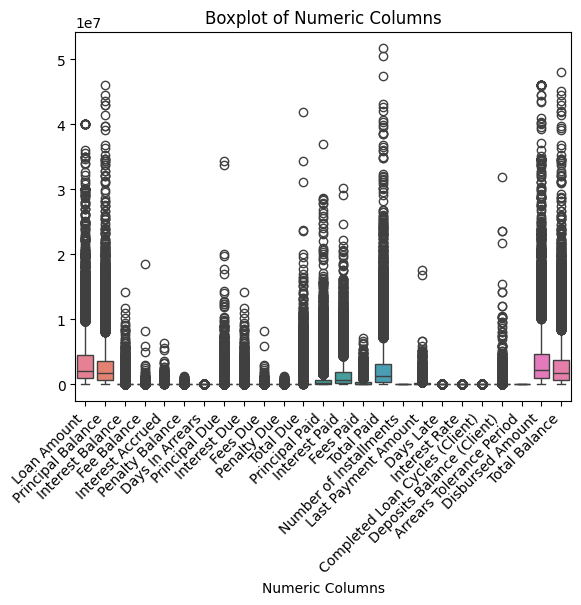

In [353]:
#checking for outliers in the numeric columns
sns.boxplot(data=df[num_cols])
plt.figsize=(12, 8)
plt.xticks(rotation=45,ha='right')
plt.title('Boxplot of Numeric Columns')
plt.xlabel('Numeric Columns')
#The boxplot shows that there are outliers in the numeric columns, especially in the 'Principal Balance', 'Interest Balance', 'Fee Balance', and 'Penalty Balance' columns. These outliers are genuine outliers.



The boxplot across all numeric columns shows heavy outlier activity, concentrated in `Principal Balance`, `Interest Balance`, `Fee Balance`, and `Penalty Balance`. These aren't data-entry errors - they reflect genuinely large loans and balances that exist in a real lending portfolio, so we don't remove them, since doing so would delete exactly the high-value or high-risk accounts the fraud and risk models most need to learn from. This does rule out models sensitive to raw scale and extreme values, which is part of why gradient-boosted trees (XGBoost/LightGBM) are the right choice for risk and loan-limit prediction: tree splits are unaffected by outlier magnitude or feature scale.

## Exploratory Data Analysis

## Univariate Analysis

Text(0, 0.5, 'Frequency')

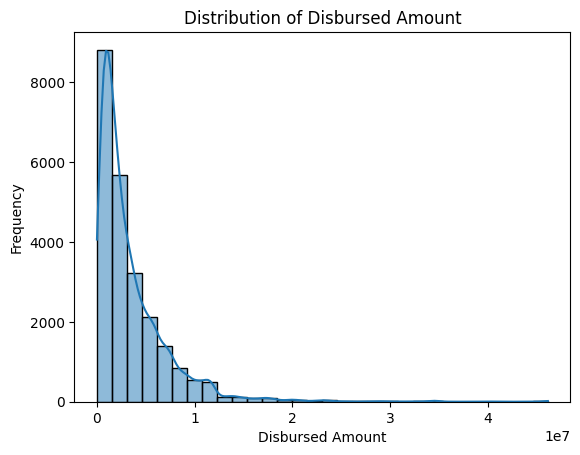

In [354]:
#loan amount distribution
sns.histplot(data=df, x='Disbursed Amount', bins=30, kde=True)
plt.title('Distribution of Disbursed Amount')
plt.xlabel('Disbursed Amount')
plt.ylabel('Frequency')
#The histogram shows the distribution of the 'Disbursed Amount' column, which appears to be right-skewed.

`Disbursed Amount` is strongly right-skewed, with a median of ~KES 2.24M against a mean of ~KES 3.49M, meaning a small number of very large disbursements pull the average well above the typical loan. A skew this strong means "average loan size" is a misleading benchmark for any single client, which reinforces why loan-limit recommendations need to be personalised per behavioural segment rather than anchored to a portfolio-wide mean, and it confirms tree-based models are the safer choice over linear regression for `Loan Limit Estimation`, since they don't assume normally distributed inputs.

Text(0, 0.5, 'Frequency')

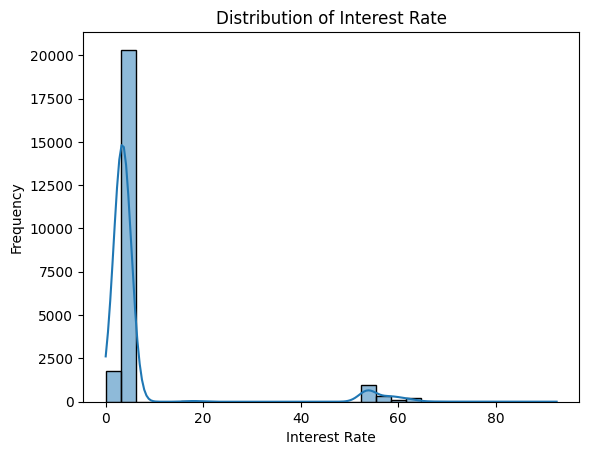

In [355]:
sns.histplot(data=df, x='Interest Rate', bins=30, kde=True)
plt.title('Distribution of Interest Rate')
plt.xlabel('Interest Rate')
plt.ylabel('Frequency')
#The histogram shows the distribution of the 'Interest Rate' column, which appears to be right-skewed, the frequency of the interest rate is higher in the lower range, indicating that most loans have a lower interest rate.

`Interest Rate` is similarly right-skewed, with most loans clustered at lower rates and a long tail of high-rate loans. Interest rate was already identified in the arrears regression as the strongest driver of `Days In Arrears`, and its skew means high-rate loans are a small but disproportionately risky minority - exactly the kind of segment K-means clustering should be able to isolate as its own behavioural group (e.g. a "high-rate, high-risk" cluster) rather than averaging it away with the bulk of low-rate loans.

Text(0, 0.5, 'Frequency')

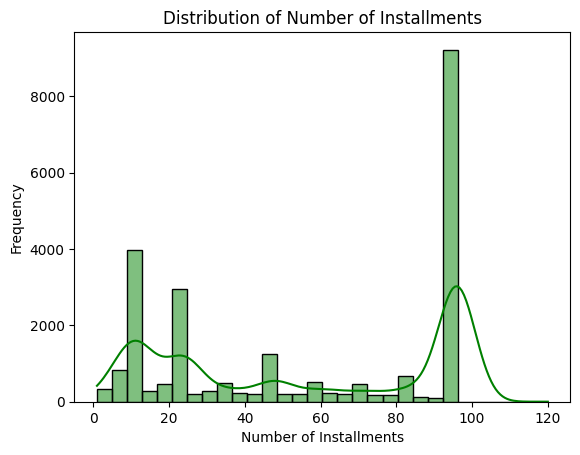

In [356]:
sns.histplot(data=df, x='Number of Installments', bins=30, kde=True,color='green')
plt.title('Distribution of Number of Installments')
plt.xlabel('Number of Installments')
plt.ylabel('Frequency')
#The histogram shows the distribution of the 'Number of Installments' column, the largest concentration occurs near 100 installments and the smaller concentration occurs near  10 - 12 installments


`Number of Installments` is close to symmetric overall  but not unimodal - there's a large concentration near 100 installments and a second, smaller concentration around 10–12. A bimodal shape like this usually means two structurally different loan types are mixed in one column (e.g. short-term vs. long-term products), which for the RFM-style feature engineering behind the Financial DNA profile is a signal to derive relative features (e.g. installments completed as a share of total) rather than using raw installment count, so short- and long-term borrowers are compared fairly within their own group.

Text(0, 0.5, 'Frequency')

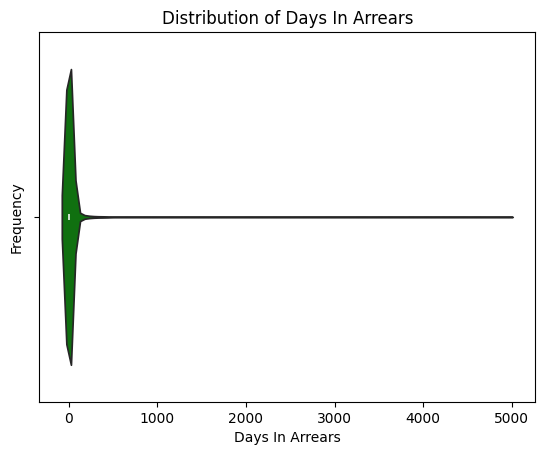

In [357]:
sns.violinplot(data=df, x='Days In Arrears',color='green')
plt.title('Distribution of Days In Arrears')
plt.xlabel('Days In Arrears')
plt.ylabel('Frequency')
#The violin plot shows the distribution of the 'Days In Arrears' column, with a higher density of observations in the lower range, indicating that most loans have a lower number of days in arrears.

`Days In Arrears` is extremely right-skewed , with a median of 0 - most accounts are current, and a long tail carries the small share of clients in serious arrears (up to nearly 4,933 days at the extreme). This is the clearest evidence for why loan-by-loan, application-time scoring misses the point: the overwhelming majority of accounts look identical (zero arrears) until the moment a small minority drift into serious delinquency. It directly motivates behavioural clustering and continuous drift-detection (the unsupervised fraud/anomaly layer) over a single static score, and it means any risk model needs to handle severe class imbalance - e.g. class weighting or resampling for XGBoost - rather than being trained on raw skewed counts.

Text(0, 0.5, 'Frequency')

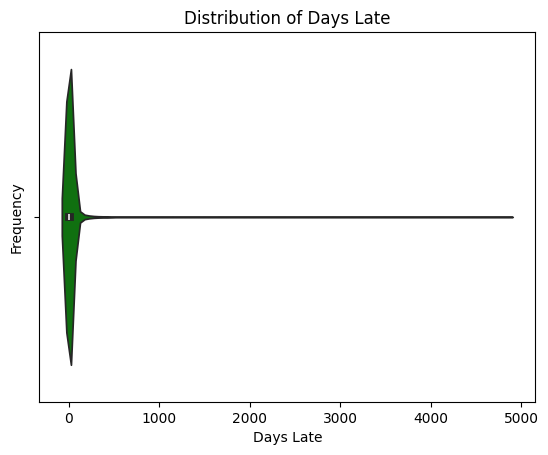

In [358]:

sns.violinplot(data=df, x='Days Late',color='green')
plt.title('Distribution of Days Late')
plt.xlabel('Days Late')
plt.ylabel('Frequency')
#The violin plot shows the distribution of the 'Days Late' column, with a higher density of observations in the lower range, indicating that most loans have a lower number of days late.


Text(0, 0.5, 'Number_of_Accounts')

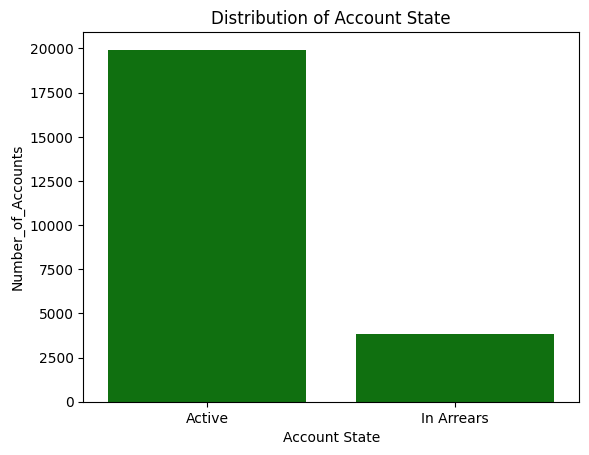

In [359]:
sns.countplot(data=df, x='Account State', color='green')
plt.title('Distribution of Account State')
plt.xlabel('Account State')
plt.ylabel('Number_of_Accounts')
#The count plot shows the distribution of the 'Account State' column, with a higher frequency of accounts in the 'Active' state, indicating that most loans are currently active.

Text(0, 0.5, 'Number_of_Accounts')

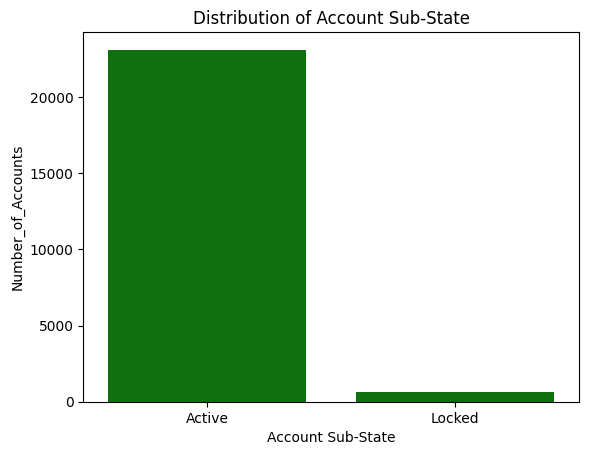

In [360]:
sns.countplot(data=df, x='Account Sub-State', color='green')
plt.title('Distribution of Account Sub-State')
plt.xlabel('Account Sub-State')
plt.ylabel('Number_of_Accounts')


Text(0, 0.5, 'Frequency')

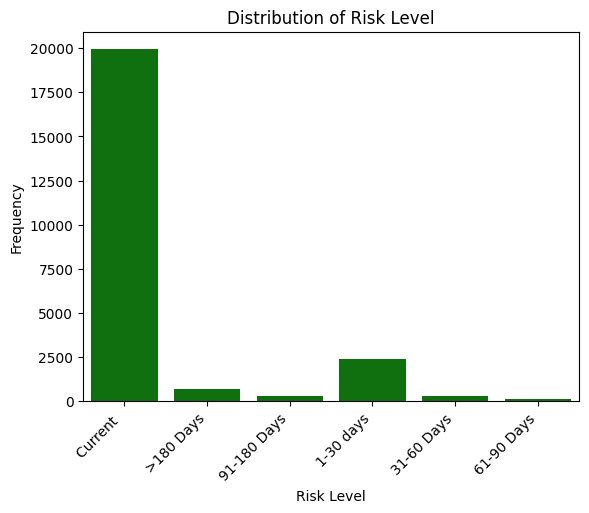

In [361]:
sns.countplot(data=df, x='Risk Level',color="green")
plt.xticks(rotation=45,ha='right')
plt.title('Distribution of Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Frequency')
#

Text(0, 0.5, 'Number_of_Accounts')

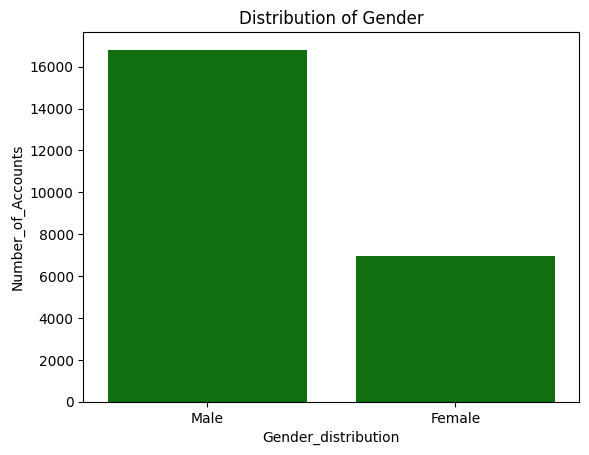

In [362]:
sns.countplot(data=df, x='Gender (Client)', color='green')
plt.title('Distribution of Gender')
plt.xlabel('Gender_distribution')
plt.ylabel('Number_of_Accounts')
#The male gender registered a higher frequency of accounts compared to the female gender


Text(0, 0.5, 'Number_of_Accounts')

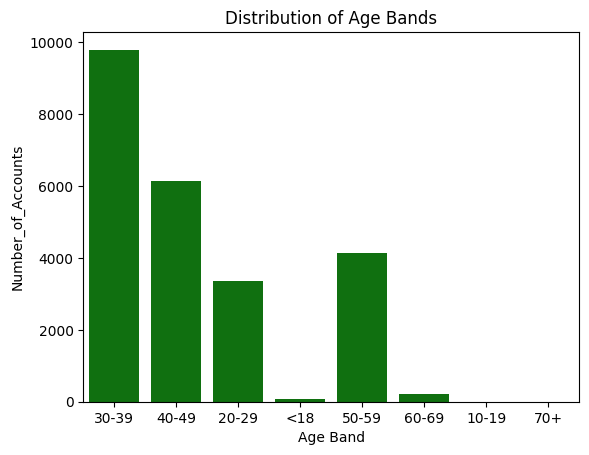

In [363]:

sns.countplot(data=df, x='Age Band (Client)', color='green')
plt.title('Distribution of Age Bands')
plt.xlabel('Age Band')
plt.ylabel('Number_of_Accounts')
#age band 30-39 registered a higher frequency of accounts compared to the other age bands


Text(0, 0.5, 'Number_of_Accounts')

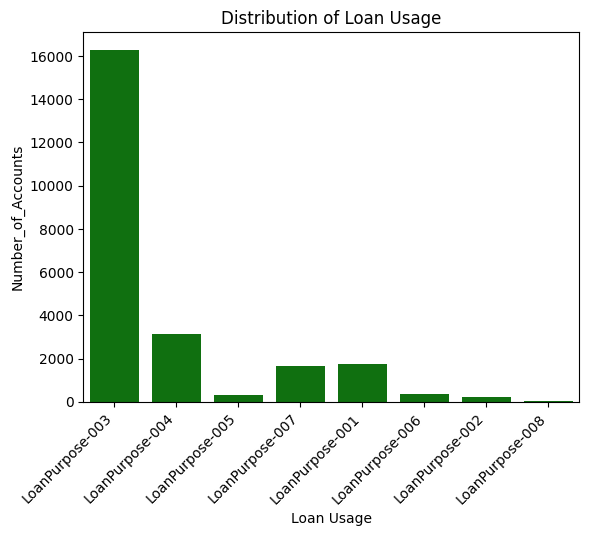

In [364]:

sns.countplot(data=df, x='Loan Usage', color='green')
plt.xticks(rotation=45,ha='right')
plt.title('Distribution of Loan Usage')
plt.xlabel('Loan Usage')
plt.ylabel('Number_of_Accounts')
#age band 30-39 registered a higher frequency of accounts compared to the other age bands


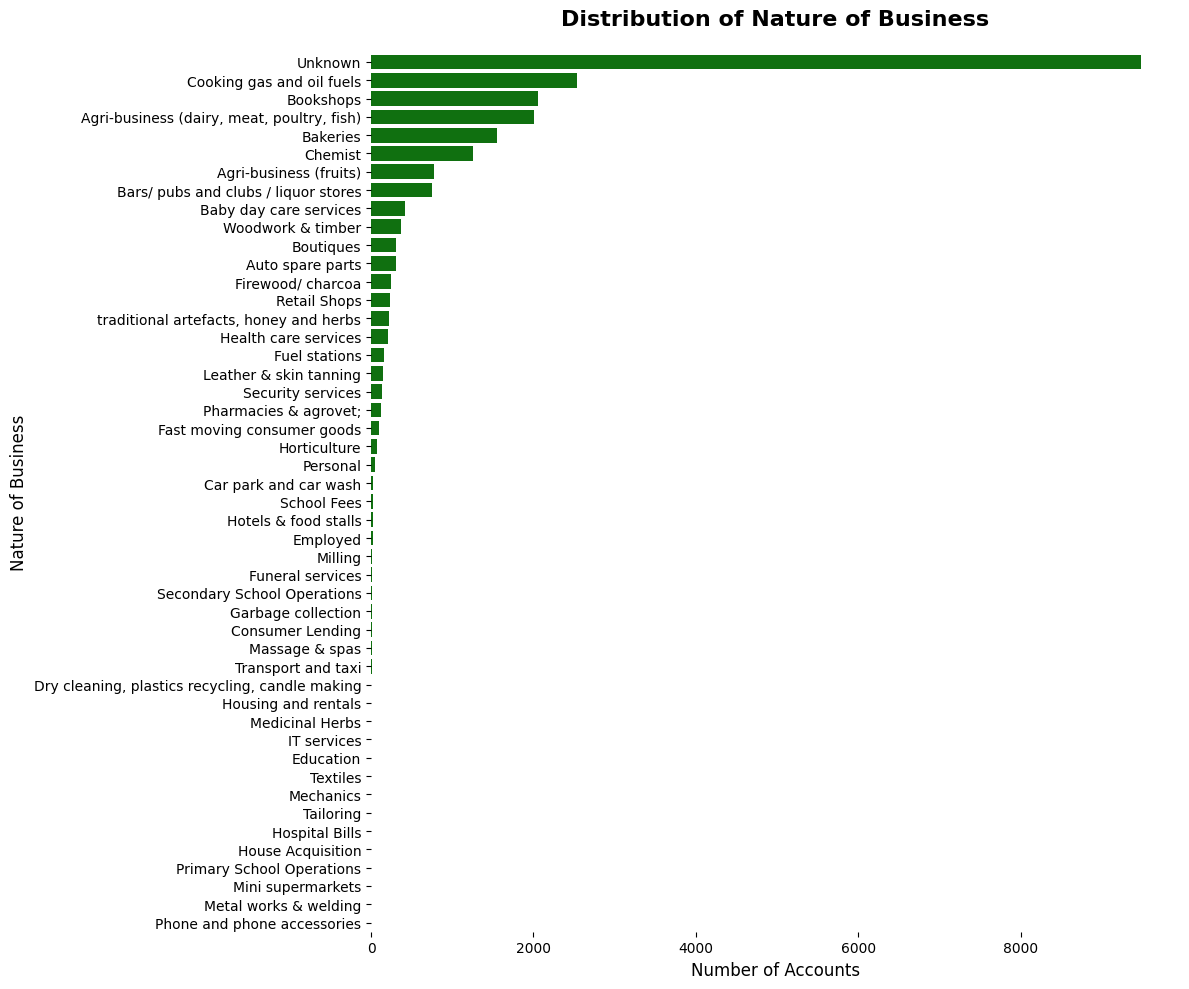

In [365]:


# 1. Set a clean, modern aesthetic style
#sns.set_theme(style="whitegrid")

# 2. Set figure size (taller height to fit long lists cleanly)
plt.figure(figsize=(12, 10))

# 3. Create a HORIZONTAL plot by switching 'x' to 'y'
# order=df['Nature of business'].value_counts().index sorts from highest to lowest
sns.countplot(
    data=df, 
    y='Nature of business', 
    color='green',
    order=df['Nature of business'].value_counts().index
)

# 4. Clean up titles and labels
plt.title('Distribution of Nature of Business', fontsize=16, pad=20, weight='bold')
plt.xlabel('Number of Accounts', fontsize=12)
plt.ylabel('Nature of Business', fontsize=12)

# 5. Remove unnecessary border lines for a minimalist look
sns.despine(left=True, bottom=True)

# 6. Prevent text clipping
plt.tight_layout()
plt.show()

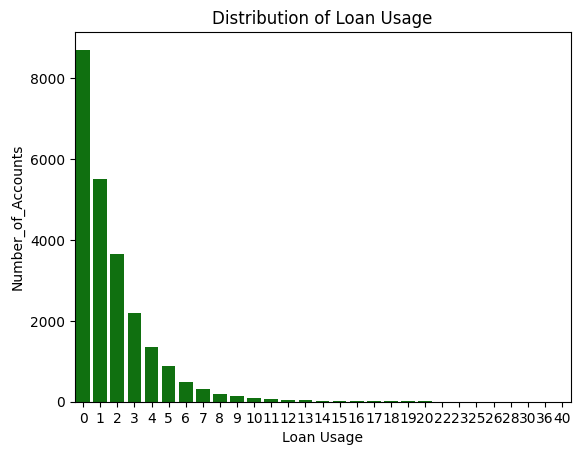

In [366]:

sns.countplot(data=df, x='Completed Loan Cycles (Client)', color='green')
#plt.xticks(rotation=45,ha='right')
plt.title('Distribution of Loan Usage')
plt.xlabel('Loan Usage')
plt.ylabel('Number_of_Accounts')
plt.show()
#New borrowers registered a higher frequency of accounts compared to repeat borrowers, indicating that the majority of loans are being taken out by new clients.


## 2 Bivariate Analysis

In [367]:
result = df.loc[df['Days In Arrears'] > 90, ['Days In Arrears', 'Loan Amount']]
print(result)

       Days In Arrears  Loan Amount
1                 2724      3060000
2                 2356      4560000
3                 1733      1540000
4                 1885      1480000
5                 2720      2840000
...                ...          ...
23685              105      4392800
23688              139      9675000
23710              435      1430000
23723              741       310000
23739              184      6078000

[1013 rows x 2 columns]


Text(0, 0.5, 'Days in Arrears')

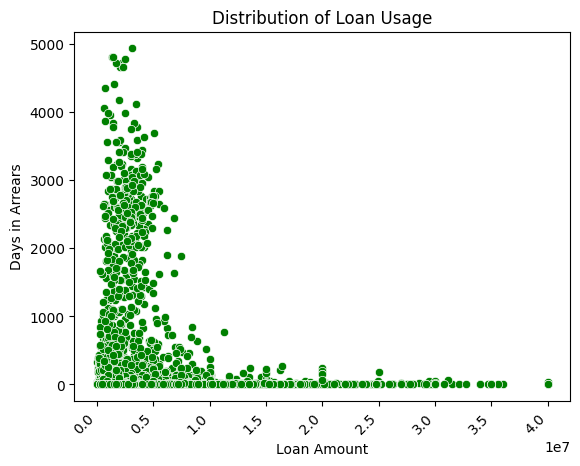

In [368]:
#Days in arrears against loan amount

sns.scatterplot(data=df, x='Loan Amount',y='Days In Arrears', color='green')
plt.xticks(rotation=45,ha='right')
plt.title('Distribution of Loan Usage')
plt.xlabel('Loan Amount')
plt.ylabel('Days in Arrears')
#The data forms a distinct "L" shape. This indicates an inverse relationship between loan size and delinquency duration-as loan size increases, maximum tolerance for delinquency drops dramatically.

#more people take smaller loans, mathematically it tracks that majority of arrears would be clustered around that bandwidth


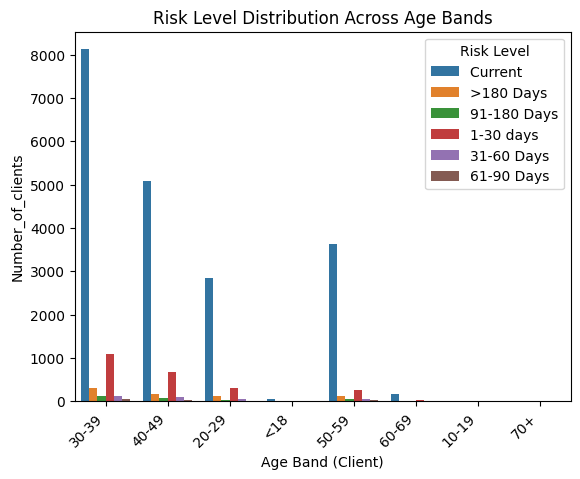

In [369]:
## Risk level against Age band

sns.countplot(data=df, x='Age Band (Client)', hue='Risk Level')
plt.xticks(rotation=45,ha='right')
plt.title('Risk Level Distribution Across Age Bands')
plt.xlabel('Age Band (Client)')
plt.ylabel('Number_of_clients')
plt.show()
#Observation Indicates that the 30–39 age group has the highest risk level, while groups like 10–19, 70+, and <18 have minimal to no visible risk level data.

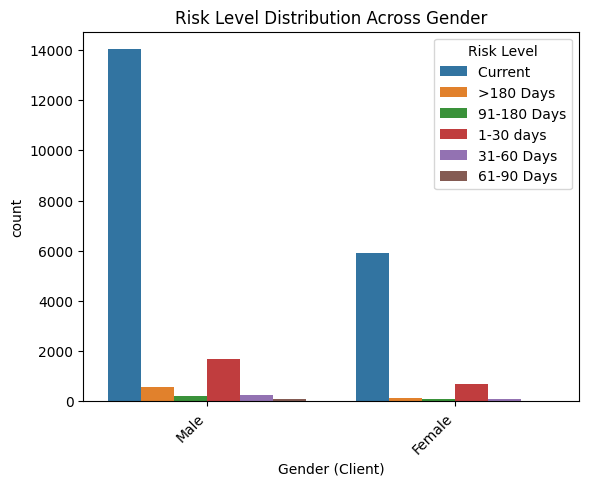

In [370]:
##Risk level against Gender
## Risk level against Gender

sns.countplot(data=df, x='Gender (Client)', hue='Risk Level')
plt.xticks(rotation=45,ha='right')
plt.title('Risk Level Distribution Across Gender')
plt.xlabel('Gender (Client)')
#plt.ylabel('Number_of_clients')
plt.show()
# The class imbalance between the genders is evident from the plot, with males having a higher frequency of accounts compared to females therefore  we can't make a definitive conclusion about the relationship between gender and risk

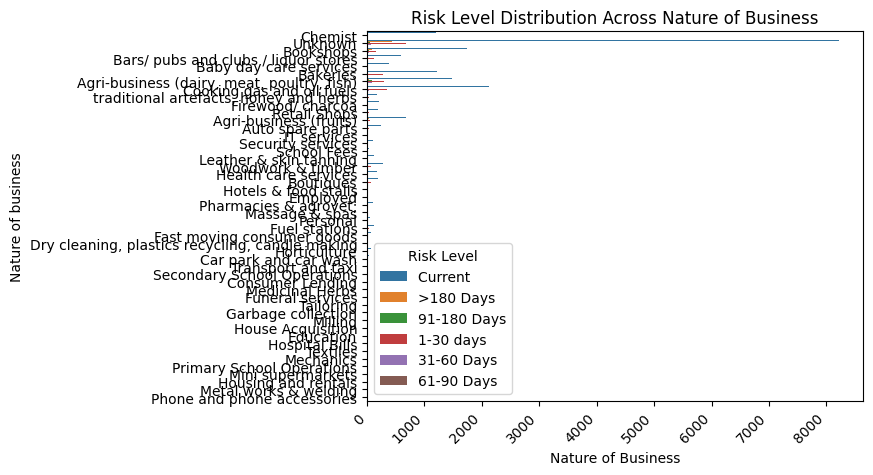

In [371]:
# Risk level against Nature of business
sns.countplot(data=df,y='Nature of business', hue=df['Risk Level'])
plt.xticks(rotation=45,ha='right')
plt.title('Risk Level Distribution Across Nature of Business')
plt.xlabel('Nature of Business')
#plt.ylabel('Number_of_clients')
plt.show()
#

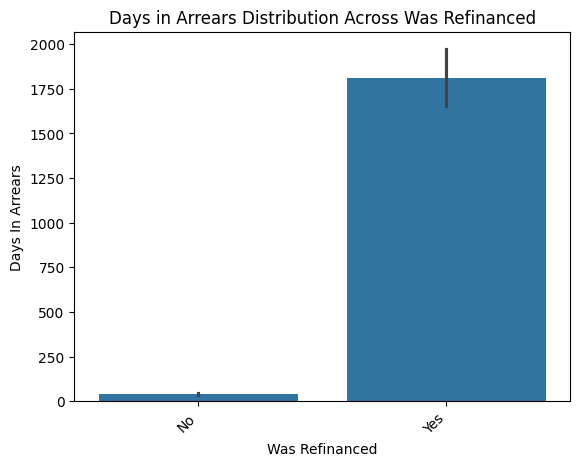

In [372]:
## Was refinanced against Arrears

sns.barplot(data=df, x='Was Refinanced',y='Days In Arrears')
plt.xticks(rotation=45,ha='right')
plt.title('Days in Arrears Distribution Across Was Refinanced')
plt.xlabel('Was Refinanced')
plt.ylabel('Days In Arrears')
plt.show()
#refinanced loans have a higher average days in arrears compared to non-refinanced loans, indicating that refinancing may be associated with higher delinquency risk.

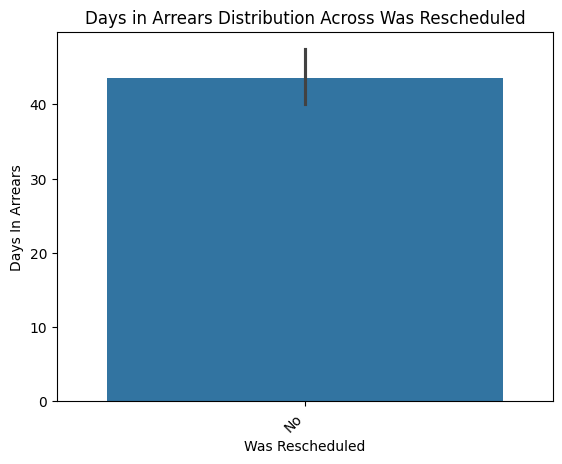

In [373]:
## Was refinanced against Arrears

sns.barplot(data=df, x='Was Rescheduled',y='Days In Arrears')
plt.xticks(rotation=45,ha='right')
plt.title('Days in Arrears Distribution Across Was Rescheduled')
plt.xlabel('Was Rescheduled')
plt.ylabel('Days In Arrears')
plt.show()
#refinanced loans have a higher average days in arrears compared to non-refinanced loans, indicating that refinancing may be associated with higher delinquency risk.

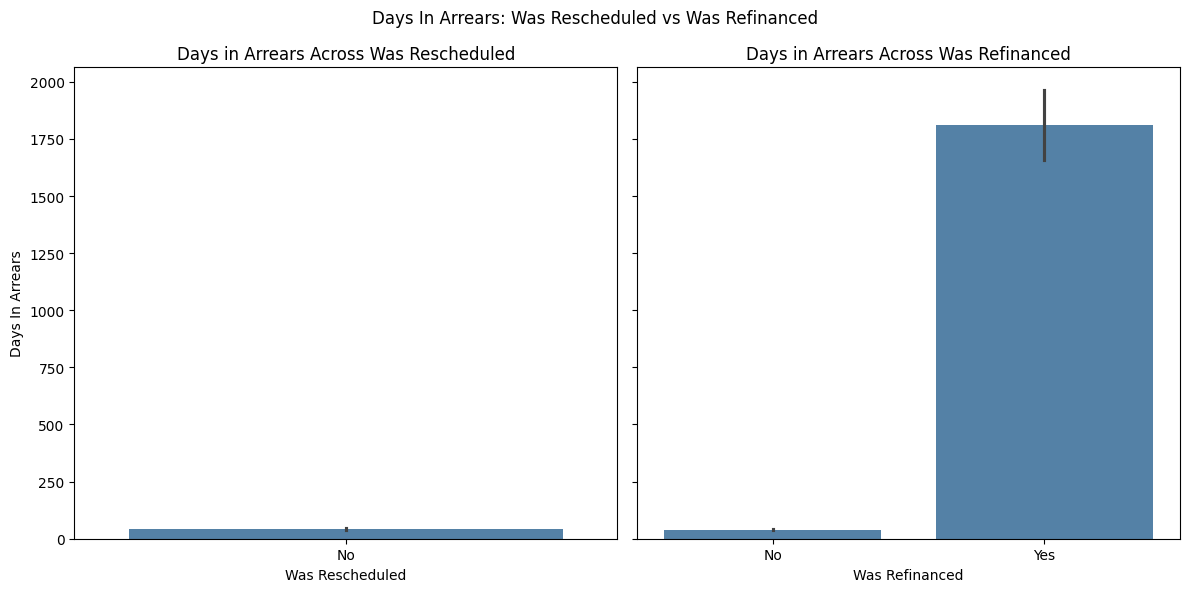

In [374]:
figure, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Left panel: Was Rescheduled vs Days In Arrears
sns.barplot(data=df, x="Was Rescheduled", y="Days In Arrears", ax=axes[0], color="steelblue")
axes[0].set_title("Days in Arrears Across Was Rescheduled")
axes[0].set_xlabel("Was Rescheduled")
axes[0].set_ylabel("Days In Arrears")

# Right panel: Was Refinanced vs Days In Arrears
sns.barplot(data=df, x="Was Refinanced", y="Days In Arrears", ax=axes[1], color="steelblue")
axes[1].set_title("Days in Arrears Across Was Refinanced")
axes[1].set_xlabel("Was Refinanced")
axes[1].set_ylabel("")

plt.suptitle("Days In Arrears: Was Rescheduled vs Was Refinanced")
plt.tight_layout()
plt.show()
#The comparison between the two panels indicates that loans that were rescheduled have a higher average days in arrears compared to those that were refinanced, suggesting that rescheduling may be associated with higher delinquency risk.

<Axes: xlabel='Loan Usage'>

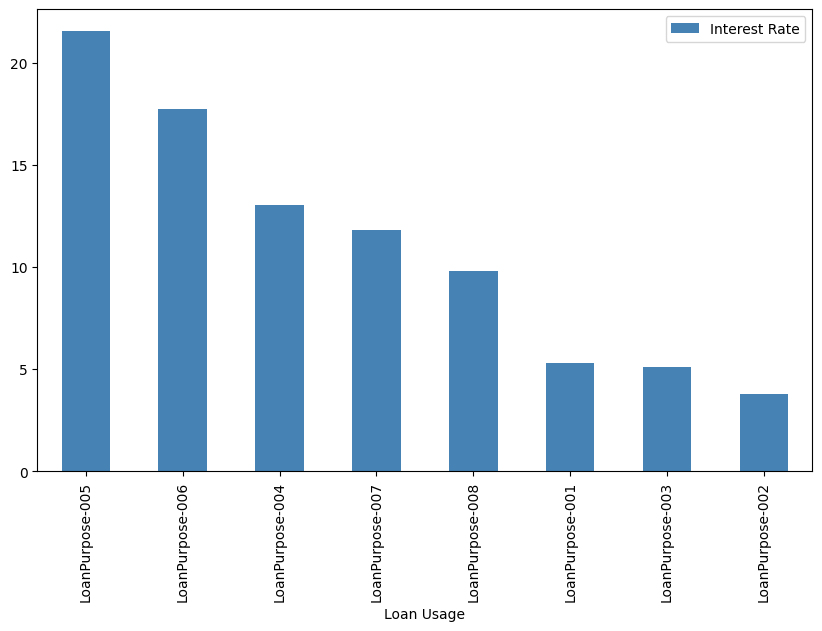

In [375]:
#interest rate  against product / loan usage
df[['Interest Rate', 'Loan Usage']].groupby('Loan Usage').mean().sort_values(by='Interest Rate', ascending=False).plot(kind='bar', figsize=(10, 6), color='steelblue')

In [376]:
df['Completed Loan Cycles (Client)']

0         0
1         0
2         1
3         0
4         0
         ..
23749     0
23750     0
23751     0
23752     0
23753    14
Name: Completed Loan Cycles (Client), Length: 23754, dtype: int64

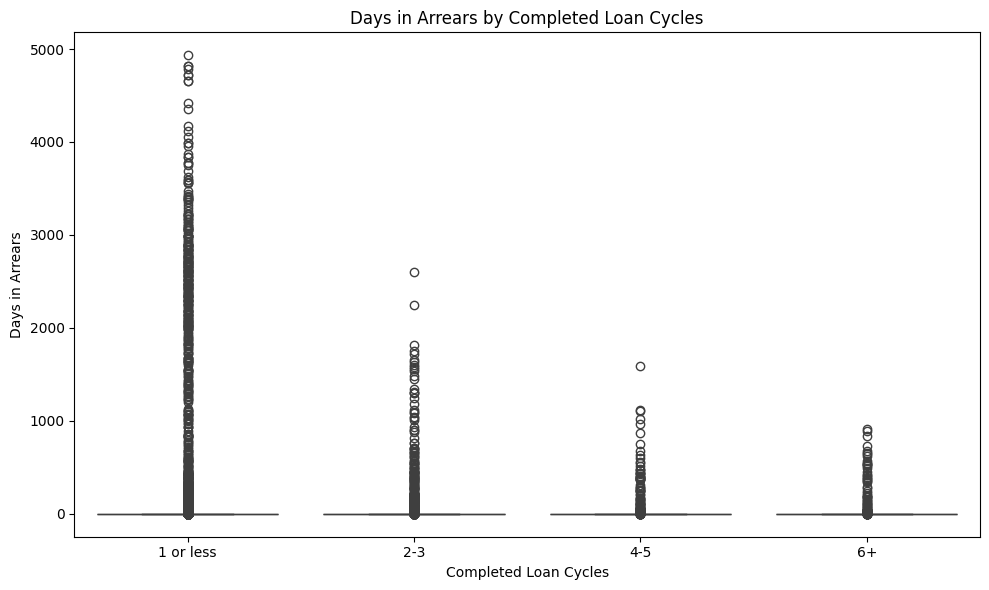

In [377]:
#Completed loan cycles against days in arrears
df['Loan_Cycle_Group'] = pd.cut(
    df['Completed Loan Cycles (Client)'],
    bins=[-1, 1, 3, 5, float('inf')],
    labels=['1 or less', '2-3', '4-5', '6+']
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Loan_Cycle_Group',
    y='Days In Arrears'
)

plt.title('Days in Arrears by Completed Loan Cycles')
plt.xlabel('Completed Loan Cycles')
plt.ylabel('Days in Arrears')

plt.tight_layout()
plt.show()
#The graph indicates that clients with more completed loan cycles tend to have higher days in arrears, suggesting a potential correlation between loan cycle frequency and delinquency risk.

## 2 Multivariate Analysis

In [378]:
df.columns

Index(['Branch', 'Account ID', 'Approval Date', 'Activation Date',
       'First Repayment Date', 'Last Payment Date', 'Product', 'Loan Amount',
       'Principal Balance', 'Interest Balance', 'Fee Balance',
       'Interest Accrued', 'Penalty Balance', 'Days In Arrears',
       'Principal Due', 'Interest Due', 'Fees Due', 'Penalty Due', 'Total Due',
       'Principal Paid', 'Interest Paid', 'Fees Paid', 'Total Paid',
       'Number of Installments', 'Account State', 'Account Sub-State',
       'Last Payment Amount', 'Expected Maturity Date', 'Gender (Client)',
       'Loan Usage', 'Was Refinanced', 'Was Rescheduled', 'Days Late',
       'Risk Level', 'Created (Client)', 'Interest Rate',
       'Loan usage Business', 'Completed Loan Cycles (Client)',
       'Deposits Balance (Client)', 'Arrears Tolerance Period',
       'Disbursed Amount', 'Environmental & Social Risk', 'Age Band (Client)',
       'Nature of business', 'Total Balance', 'Has Made Last Payment',
       'Loan_Cycle_Group'

In [379]:
num_cols

['Loan Amount',
 'Principal Balance',
 'Interest Balance',
 'Fee Balance',
 'Interest Accrued',
 'Penalty Balance',
 'Days In Arrears',
 'Principal Due',
 'Interest Due',
 'Fees Due',
 'Penalty Due',
 'Total Due',
 'Principal Paid',
 'Interest Paid',
 'Fees Paid',
 'Total Paid',
 'Number of Installments',
 'Last Payment Amount',
 'Days Late',
 'Interest Rate',
 'Completed Loan Cycles (Client)',
 'Deposits Balance (Client)',
 'Arrears Tolerance Period',
 'Disbursed Amount',
 'Total Balance']

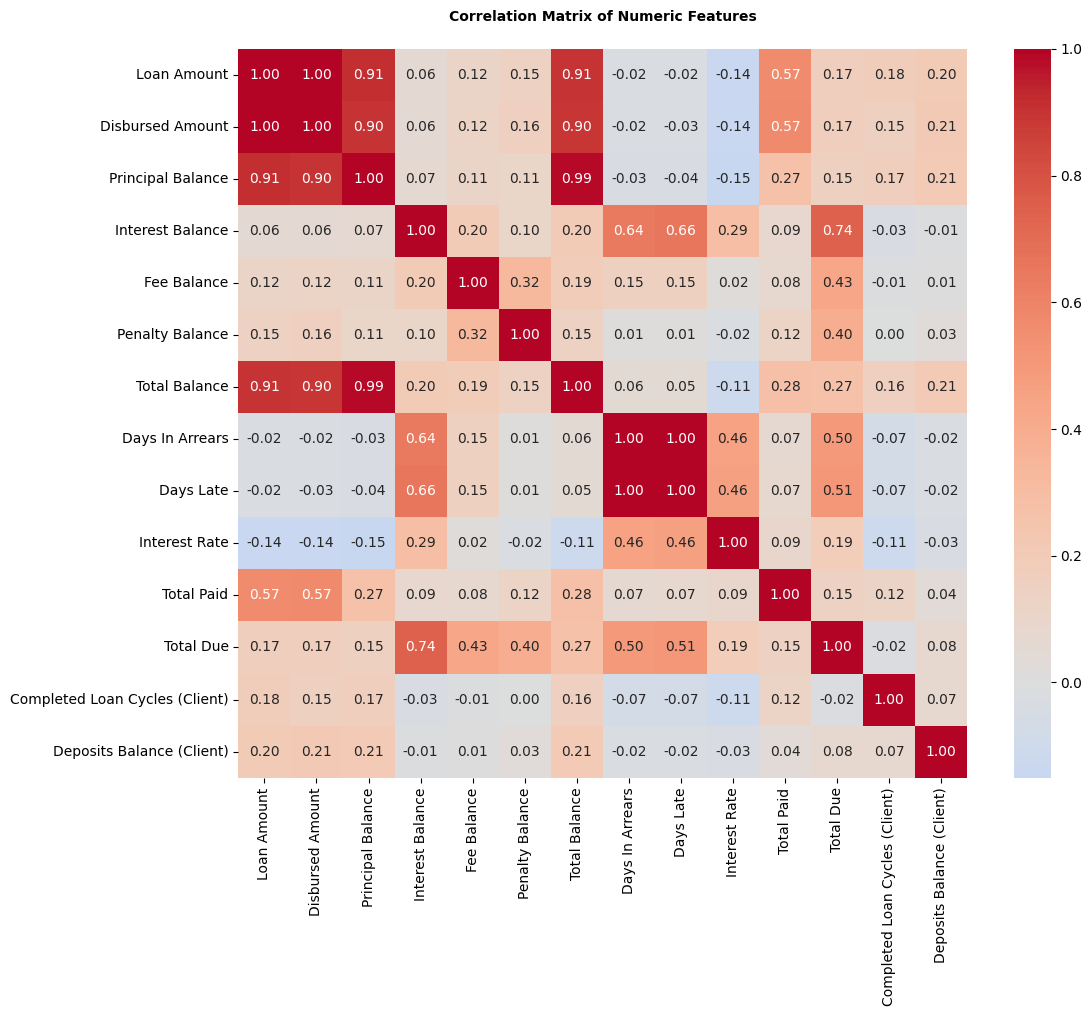

In [380]:
## correlation matrix
"""Days In Arrears/Days Late, Loan Amount/ Disbursed Amount perfectly correlated - drop one... Total Balance/Principal Balance - strong correlation signal"""
repay_bv = ["Loan Amount", "Disbursed Amount", "Principal Balance", "Interest Balance",
           "Fee Balance", "Penalty Balance", "Total Balance", "Days In Arrears",
           "Days Late", "Interest Rate", "Total Paid", "Total Due",
           "Completed Loan Cycles (Client)", "Deposits Balance (Client)"] 
corr = df[repay_bv].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,)
plt.title('Correlation Matrix of Numeric Features', fontsize=10, pad=20, weight='bold')
plt.tight_layout()
plt.show()

In [381]:
## VIF (Variance Inflation Factor) to check for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_cols = ['Loan Amount', 'Principal Balance', 'Interest Balance', 'Fee Balance', 'Penalty Balance', 'Days In Arrears','Interest Rate',
            'Total Paid', 'Total Due', 'Number of Installments','Last Payment Amount', 'Arrears Tolerance Period', 'Completed Loan Cycles (Client)',
            'Deposits Balance (Client)']
X_vif = df[vif_cols].dropna()  # Drop rows with NaN values for VIF calculation
X_vif = (X_vif - X_vif.mean()) / X_vif.std()  # Standardize the data
vif_data = pd.DataFrame({
    'feature': vif_cols,
    'VIF' : [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_cols))]
})
print(vif_data.sort_values(by='VIF', ascending=False))

                           feature        VIF
0                      Loan Amount  25.640476
1                Principal Balance  17.158256
7                       Total Paid   4.044602
8                        Total Due   3.417908
2                 Interest Balance   3.189398
9           Number of Installments   2.339111
11        Arrears Tolerance Period   2.237855
5                  Days In Arrears   2.046198
6                    Interest Rate   1.817828
10             Last Payment Amount   1.589102
4                  Penalty Balance   1.373628
3                      Fee Balance   1.312276
13       Deposits Balance (Client)   1.127184
12  Completed Loan Cycles (Client)   1.075575


In [382]:
## dropping highly correlated features
df = df.drop(columns=['Disbursed Amount'])

In [383]:
#does refinancing or rescheduling actually cause higher arrears?
import statsmodels.formula.api as smf
reg_df = df[['Loan Amount', 'Interest Rate', 'Days In Arrears', 'Was Refinanced', 'Was Rescheduled']].dropna()
model = smf.ols(
    'Q("Days In Arrears") ~ Q("Loan Amount") + Q("Interest Rate") '
    '+ C(Q("Was Refinanced")) + C(Q("Was Rescheduled"))',
    data=reg_df
).fit()
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     Q("Days In Arrears")   R-squared:                       0.247
Model:                              OLS   Adj. R-squared:                  0.247
Method:                   Least Squares   F-statistic:                     2601.
Date:                  Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                          18:50:56   Log-Likelihood:            -1.6596e+05
No. Observations:                 23754   AIC:                         3.319e+05
Df Residuals:                     23750   BIC:                         3.320e+05
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [384]:
print(df['Was Rescheduled'].value_counts(dropna=False))
print(reg_df['Was Rescheduled'].value_counts(dropna=False))

Was Rescheduled
No    23754
Name: count, dtype: int64
Was Rescheduled
No    23754
Name: count, dtype: int64


In [385]:
df = df.drop(columns=['Was Rescheduled'])

In [386]:
reg_df = df[["Days In Arrears", "Loan Amount", "Interest Rate", "Was Refinanced"]].dropna()
model = smf.ols(
    'Q("Days In Arrears") ~ Q("Loan Amount") + Q("Interest Rate") + C(Q("Was Refinanced"))',
    data=reg_df
).fit()
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     Q("Days In Arrears")   R-squared:                       0.247
Model:                              OLS   Adj. R-squared:                  0.247
Method:                   Least Squares   F-statistic:                     2601.
Date:                  Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                          18:50:56   Log-Likelihood:            -1.6596e+05
No. Observations:                 23754   AIC:                         3.319e+05
Df Residuals:                     23750   BIC:                         3.320e+05
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

### Multiple Regression: Days In Arrears ~ Loan Amount + Interest Rate + Was Refinanced

**Purpose:** Isolate whether refinancing, loan size, and interest rate each independently
predict arrears, controlling for the others - rather than reading single-variable
comparisons (as in the earlier bivariate bar charts) that can't separate a variable's
own effect from confounds.

**Data note:** `Was Rescheduled` was originally included but dropped - it turned out to
be `No` for all 23,754 rows (zero variance across the entire dataset). This also means
the earlier bivariate conclusion that "rescheduled loans have higher arrears" is invalid;
there is no rescheduled group to compare against. `Was Rescheduled` is excluded from all
further analysis and from the Component 4 anomaly-detection feature list.

**Model fit:** R² = 0.247 (F = 2601, p < 0.001) - these three predictors jointly explain
~25% of the variation in Days In Arrears. The remaining ~75% comes from factors outside
this model (branch, product, individual account circumstances, etc.).

**Findings:**
- **Was Refinanced (Yes vs No):** +1,253 days in arrears on average, holding loan amount
  and interest rate constant (t = 33.2, p < 0.001). Large and highly significant, though
  worth confirming it isn't driven by a small number of extreme accounts within the
  ~50-row refinanced group before treating it as a broad pattern.
- **Interest Rate:** +9.64 days in arrears per 1-point increase in rate, holding loan
  amount and refinance status constant (t = 74.2, p < 0.001). The strongest, most robust
  driver in the model.
- **Loan Amount:** +3.45 days in arrears per additional 1,000,000 in loan amount, holding
  rate and refinance status constant (p < 0.001). Notable because the raw pairwise
  correlation between Loan Amount and Days In Arrears was near zero (-0.02) - the true
  positive relationship only appears once Interest Rate is controlled for, since larger
  loans tend to carry slightly lower rates, which was masking the effect in the
  uncontrolled comparison.

**Caveats:** Residuals are heavily right-skewed (skew = 7.0, kurtosis = 78.2), so p-values
are approximate rather than exact - though the effects here are large enough that the
directional conclusions hold regardless. The condition-number warning is most likely a
scale artifact (Loan Amount is in the millions vs. a 0–100 interest rate and a 0/1 dummy),
not genuine multicollinearity - VIF checked separately confirmed Loan Amount and Interest
Rate aren't collinear with each other.

**Implication for the project:** Was Refinanced and Interest Rate are strong, independently
verified candidates for the risk model's feature set / instability flags. Loan Amount's
effect, while real, is small in practical terms. Was Rescheduled is dropped from all
downstream components as an uninformative column.

In [387]:
log_df = df[["Days In Arrears", "Loan Amount", "Interest Rate", "Gender (Client)"]].dropna().copy()
log_df['High Arrears'] = (log_df['Days In Arrears'] > log_df['Days In Arrears'].median()).astype(int)
logit = smf.logit(
    'Q("High Arrears") ~ Q("Loan Amount") + Q("Interest Rate") + C(Q("Gender (Client)"))',
    data=log_df
).fit(disp=0)
print(logit.summary())
print(np.exp(logit.params).round(3))  # Exponentiated coefficients for interpretation

                           Logit Regression Results                           
Dep. Variable:      Q("High Arrears")   No. Observations:                23754
Model:                          Logit   Df Residuals:                    23750
Method:                           MLE   Df Model:                            3
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                 0.06952
Time:                        18:50:56   Log-Likelihood:                -9753.8
converged:                       True   LL-Null:                       -10483.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -2.1711      0.040    -53.618      0.000      -2.250      -2.092
C(Q("Gender (Client)"))[T.Male]     0.0737      0.041      1.789    

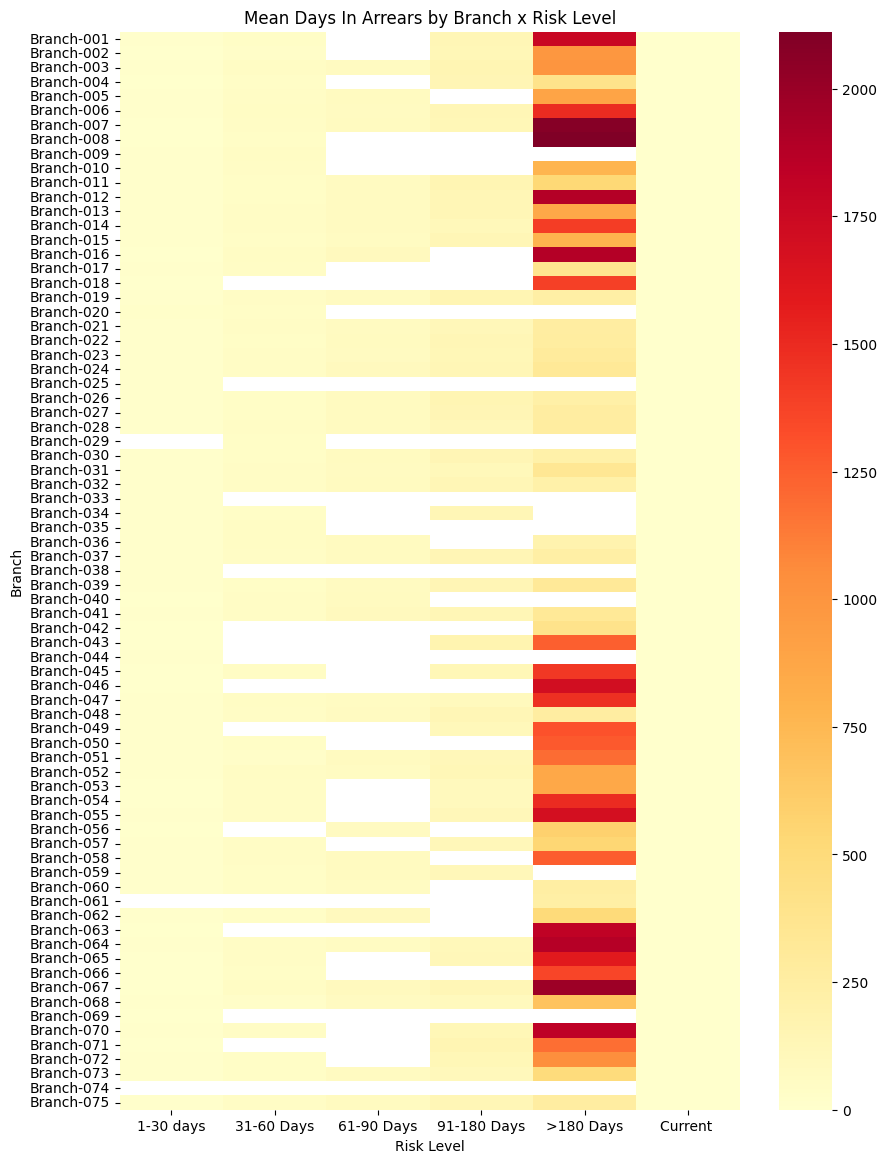

In [388]:
pivot = df.pivot_table(values="Days In Arrears", index="Branch", columns="Risk Level", aggfunc="mean")
plt.figure(figsize=(10, 14))
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Mean Days In Arrears by Branch x Risk Level")
plt.show()

Explained variance: [0.372 0.226 0.117]
                    PC1   PC2   PC3
Principal Balance  0.22  0.05  0.13
Interest Balance   0.14  0.51 -0.55
Fee Balance        0.14  0.41  0.40
Penalty Balance    0.16  0.33  0.61
Principal Paid     0.42 -0.16  0.16
Interest Paid      0.41 -0.13 -0.30
Fees Paid          0.48 -0.19  0.05
Total Paid         0.52 -0.18 -0.07
Total Due          0.20  0.59 -0.18


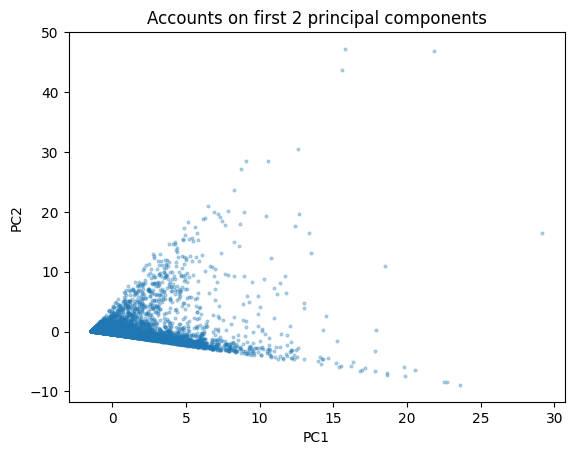

In [389]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_cols = ["Principal Balance", "Interest Balance", "Fee Balance", "Penalty Balance",
            "Principal Paid", "Interest Paid", "Fees Paid", "Total Paid", "Total Due"]
pca_data = df[pca_cols].dropna()
X_scaled = StandardScaler().fit_transform(pca_data)
pca = PCA(n_components=3)
components = pca.fit_transform(X_scaled)
print("Explained variance:", pca.explained_variance_ratio_.round(3))

loadings = pd.DataFrame(pca.components_.T, index=pca_cols, columns=["PC1", "PC2", "PC3"])
print(loadings.round(2))

plt.scatter(components[:, 0], components[:, 1], s=4, alpha=0.3)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Accounts on first 2 principal components")
plt.show()

         Repayment Ratio  Days In Arrears  Loan Amount  Interest Rate
Segment                                                              
0                   3.64          2546.27   2727630.03          62.65
1                  30.66            30.00   3004850.21           3.40
2                 709.32            14.65   4219515.82           3.82
3                  61.57            48.73   1059012.86          55.04


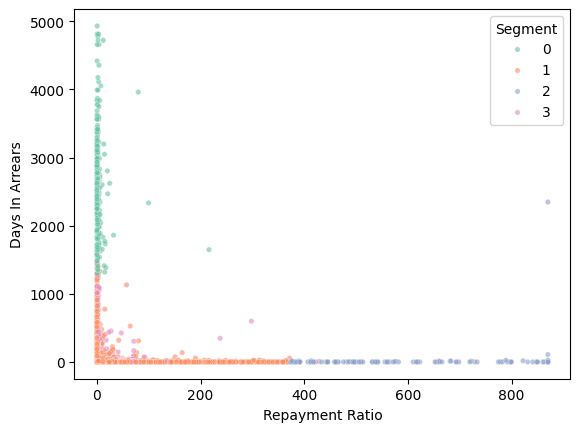

In [390]:
from sklearn.cluster import KMeans


seg_df = df.copy()
seg_df["Repayment Ratio"] = seg_df["Total Paid"] / seg_df["Total Due"].replace(0, np.nan)
seg_df = seg_df[seg_df["Total Due"] > 1000]
seg_df["Repayment Ratio"] = seg_df["Repayment Ratio"].clip(upper=seg_df["Repayment Ratio"].quantile(0.99))

seg_cols = ["Repayment Ratio", "Days In Arrears", "Loan Amount", "Interest Rate"]
seg_data = seg_df[seg_cols].replace([np.inf, -np.inf], np.nan).dropna()

X_cluster = StandardScaler().fit_transform(seg_data)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
seg_data["Segment"] = kmeans.fit_predict(X_cluster)

print(seg_data.groupby("Segment")[seg_cols].mean().round(2))
sns.scatterplot(data=seg_data, x="Repayment Ratio", y="Days In Arrears",
                 hue="Segment", palette="Set2", s=15, alpha=0.6)
plt.show()

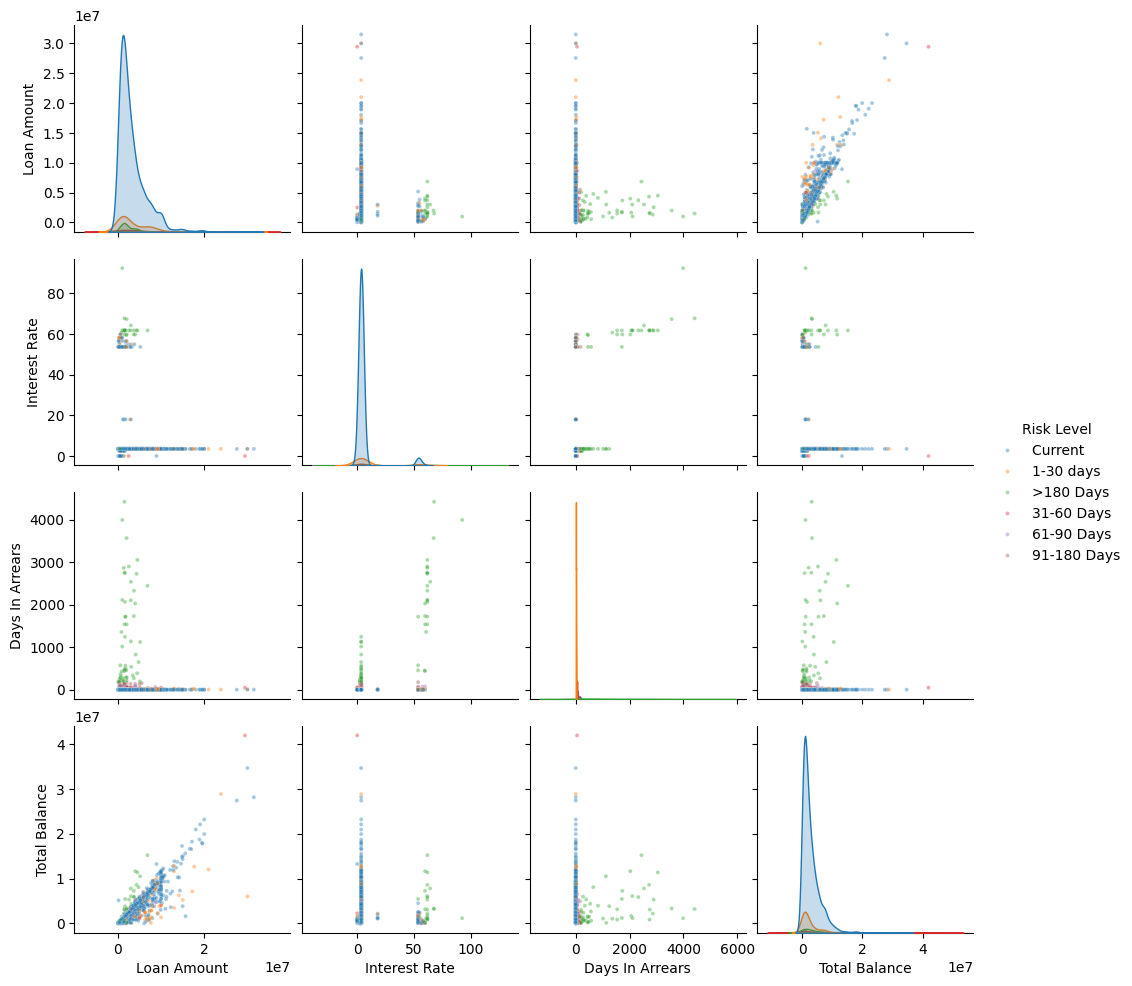

In [391]:
pair_cols = ["Loan Amount", "Interest Rate", "Days In Arrears", "Total Balance"]
sample = df[pair_cols + ["Risk Level"]].dropna().sample(n=2000, random_state=42)
sns.pairplot(sample, vars=pair_cols, hue="Risk Level", plot_kws={"s": 8, "alpha": 0.4})
plt.show()

In [392]:
df.columns

Index(['Branch', 'Account ID', 'Approval Date', 'Activation Date',
       'First Repayment Date', 'Last Payment Date', 'Product', 'Loan Amount',
       'Principal Balance', 'Interest Balance', 'Fee Balance',
       'Interest Accrued', 'Penalty Balance', 'Days In Arrears',
       'Principal Due', 'Interest Due', 'Fees Due', 'Penalty Due', 'Total Due',
       'Principal Paid', 'Interest Paid', 'Fees Paid', 'Total Paid',
       'Number of Installments', 'Account State', 'Account Sub-State',
       'Last Payment Amount', 'Expected Maturity Date', 'Gender (Client)',
       'Loan Usage', 'Was Refinanced', 'Days Late', 'Risk Level',
       'Created (Client)', 'Interest Rate', 'Loan usage Business',
       'Completed Loan Cycles (Client)', 'Deposits Balance (Client)',
       'Arrears Tolerance Period', 'Environmental & Social Risk',
       'Age Band (Client)', 'Nature of business', 'Total Balance',
       'Has Made Last Payment', 'Loan_Cycle_Group'],
      dtype='object')

## Component 1 - Financial DNA Profile (Behavioural Segmentation)

We formalise the exploratory clustering above into the actual Financial DNA profile: a bounded, well-behaved RFM feature set, a data-driven choice of k via silhouette score, and named segments a loan officer can actually read.

In [393]:
snapshot_date = df[['Approval Date', 'Activation Date', 'Last Payment Date']].max().max()

# Recency
df['Days Since Last Payment'] = (snapshot_date - df['Last Payment Date']).dt.days
df['Days Since Last Payment'] = df['Days Since Last Payment'].fillna(
    (snapshot_date - df['Approval Date']).dt.days
)

# Frequency
df['Loan Frequency'] = df['Completed Loan Cycles (Client)']

For the Monetary/behavioural signal, `Total Paid / Total Due` blows up toward infinity as `Total Due` approaches zero for nearly-closed loans. We use the bounded form instead - share of total obligation already paid — which stays in [0, 1] regardless of how close to fully repaid a loan is.

In [394]:
denom = (df['Total Paid'] + df['Total Due']).replace(0, np.nan)
df['Repayment Ratio'] = (df['Total Paid'] / denom).fillna(1.0).clip(0, 1)

rfm_cols = ['Repayment Ratio', 'Days In Arrears', 'Days Since Last Payment',
            'Loan Frequency', 'Loan Amount', 'Total Balance']
seg_data = df[rfm_cols].replace([np.inf, -np.inf], np.nan).dropna()

Rather than assuming k=4, we check silhouette score across a small range so the choice is data-driven, not inherited from the earlier exploratory pass.

In [395]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_seg = StandardScaler().fit_transform(seg_data)

for k in [3, 4, 5]:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_seg)
    score = silhouette_score(X_seg, labels, sample_size=5000, random_state=42)
    print(f"k={k}  silhouette={score:.4f}")

k=3  silhouette=0.4102
k=4  silhouette=0.4190
k=5  silhouette=0.3684


Silhouette peaks at **k=4** (0.419 vs. 0.410 for k=3 and 0.368 for k=5) - confirming 4 segments rather than assuming it.

In [396]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
seg_data['Segment'] = kmeans.fit_predict(X_seg)

profile = seg_data.groupby('Segment')[rfm_cols].mean().round(2)
profile['pct'] = (seg_data.groupby('Segment').size() / len(seg_data) * 100).round(1)
print(profile)

         Repayment Ratio  Days In Arrears  Days Since Last Payment  \
Segment                                                              
0                   0.98             4.31                   107.17   
1                   0.97             2.43                   102.48   
2                   0.33           179.73                   207.20   
3                   0.52          2539.58                   116.93   

         Loan Frequency  Loan Amount  Total Balance   pct  
Segment                                                    
0                  1.38   1917151.37     1564728.56  74.1  
1                  3.22   8356297.74     7278163.14  20.1  
2                  1.65   2735862.94     3146038.35   4.6  
3                  0.26   2737758.78     4475584.12   1.2  


Reading the fitted profile: Segment 0, **"Reliable Payer"** (74.1%), repayment ratio 0.975, 4.3 days in arrears - the healthy mainstream. Segment 1, **"Established Repeat Borrower"** (20.1%), repays just as well (0.974) but with far larger loans (~KES 8.4M vs ~1.9M) and more completed cycles (3.2 vs 1.4) — highest-value clients. Segment 2, **"At-Risk / Currently Delinquent"** (4.6%), repayment ratio 0.33, 180 days in arrears. Segment 3, **"Chronic Defaulter"** (1.2%), repayment ratio 0.52 but 2,540 days in arrears on average - essentially written-off accounts.

In [397]:
segment_names = {0: 'Reliable Payer', 1: 'Established Repeat Borrower',
                  2: 'At-Risk / Currently Delinquent', 3: 'Chronic Defaulter'}
seg_data['Segment Name'] = seg_data['Segment'].map(segment_names)
df.loc[seg_data.index, 'Financial DNA Segment'] = seg_data['Segment Name']

## Component 2 - Risk / Arrears Prediction


Target: `Account State` (In Arrears vs. Active). Features are restricted to what's knowable at or near origination — every column describing how *this* loan already performed (`Days In Arrears`, `Days Late`, `Risk Level`, balances, `Repayment Ratio`) is excluded, since using it would just re-derive the label from itself.

In [398]:
df['Loan Age Days'] = (snapshot_date - df['Approval Date']).dt.days

cat_features = ['Branch', 'Product', 'Gender (Client)', 'Age Band (Client)',
                'Loan Usage', 'Loan usage Business', 'Nature of business',
                'Was Refinanced', 'Environmental & Social Risk']
num_features = ['Loan Amount', 'Interest Rate', 'Number of Installments',
                 'Completed Loan Cycles (Client)', 'Deposits Balance (Client)',
                 'Arrears Tolerance Period', 'Loan Age Days']

risk_df = df[cat_features + num_features + ['Account State']].dropna().copy()
y = (risk_df['Account State'] == 'In Arrears').astype(int)

We split into train / validation / test — validation is what the hyperparameter search will optimise against, test stays untouched until the very end so the reported score isn't inflated by tuning against it.

In [399]:
from sklearn.model_selection import train_test_split

X_full = risk_df[cat_features + num_features].copy()
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

`Branch` (75 categories) and `Product` (101 categories) are high-cardinality - plain category splits don't fully exploit them. We target-encode both as their historical arrears rate, fitting the mapping on the *training* fold only so validation/test don't leak into their own encoding.

In [400]:
def target_encode(train_x, train_y, other_x, col):
    means = train_y.groupby(train_x[col]).mean()
    return other_x[col].map(means).fillna(train_y.mean())

for col in ['Branch', 'Product']:
    enc_name = f'{col} Arrears Rate'
    X_train[enc_name] = target_encode(X_train, y_train, X_train, col)
    X_val[enc_name] = target_encode(X_train, y_train, X_val, col)
    X_test[enc_name] = target_encode(X_train, y_train, X_test, col)

encoded_num_features = num_features + ['Branch Arrears Rate', 'Product Arrears Rate']
feature_cols = cat_features + encoded_num_features

for c in cat_features:
    X_train[c] = X_train[c].astype('category')
    X_val[c] = X_val[c].astype('category')
    X_test[c] = X_test[c].astype('category')

**Hyperparameter tuning (Optuna).** We optimise PR-AUC rather than accuracy or plain ROC-AUC - with a ~16% positive rate, PR-AUC is the metric least likely to flatter a model that just leans on the majority class.

In [401]:
import optuna
from sklearn.metrics import average_precision_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'class_weight': 'balanced',
        'random_state': 42, 'verbose': -1,
    }
    from lightgbm import LGBMClassifier
    m = LGBMClassifier(**params)
    m.fit(X_train[feature_cols], y_train, categorical_feature=cat_features)
    proba = m.predict_proba(X_val[feature_cols])[:, 1]
    return average_precision_score(y_val, proba)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30)
print("Best val PR-AUC:", round(study.best_value, 4))
print(study.best_params)

Best val PR-AUC: 0.5966
{'n_estimators': 459, 'num_leaves': 47, 'max_depth': 9, 'learning_rate': 0.01518747922672247, 'min_child_samples': 33, 'subsample': 0.7465447373174767, 'colsample_bytree': 0.7824279936868144, 'reg_alpha': 1.382623217936987, 'reg_lambda': 0.006290644294586149}


30 trials found a validation PR-AUC of 0.597. Now retrain on train+validation combined with the winning parameters, and evaluate once on the untouched test set.

In [402]:
from lightgbm import LGBMClassifier

best_params = dict(study.best_params, class_weight='balanced', random_state=42, verbose=-1)
risk_model = LGBMClassifier(**best_params)

X_trainval_enc = pd.concat([X_train, X_val])
y_trainval_enc = pd.concat([y_train, y_val])
for c in cat_features:
    X_trainval_enc[c] = X_trainval_enc[c].astype('category')

risk_model.fit(X_trainval_enc[feature_cols], y_trainval_enc, categorical_feature=cat_features)
test_proba = risk_model.predict_proba(X_test[feature_cols])[:, 1]

In [403]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

print("Test ROC-AUC:", round(roc_auc_score(y_test, test_proba), 4))
print("Test PR-AUC :", round(average_precision_score(y_test, test_proba), 4))
print(classification_report(y_test, (test_proba >= 0.5).astype(int), digits=3))

Test ROC-AUC: 0.8747
Test PR-AUC : 0.5885
              precision    recall  f1-score   support

           0      0.948     0.794     0.864      3986
           1      0.419     0.774     0.544       765

    accuracy                          0.791      4751
   macro avg      0.684     0.784     0.704      4751
weighted avg      0.863     0.791     0.813      4751



Test PR-AUC: 0.589 (up from 0.577 untuned/unencoded - a real but modest gain, since the ceiling here is set by the leakage-safe feature restriction, not by tuning effort). At the default 0.5 threshold: precision 0.419, recall 0.774, F1 0.544.

**Threshold tuning is the free lever.** 0.5 isn't a meaningful cutoff for an imbalanced target - we scan the precision-recall curve to find the threshold matching the business priority. Missing a real default is costlier than one extra manual review, so F2 (recall-weighted) is the more defensible choice here over F1.

In [404]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, test_proba)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
f2s = 5 * precisions * recalls / (4 * precisions + recalls + 1e-9)

best_f1 = thresholds[np.argmax(f1s)]
best_f2 = thresholds[np.argmax(f2s)]
print(f"Best-F1 threshold={best_f1:.3f}  precision={precisions[np.argmax(f1s)]:.3f}  recall={recalls[np.argmax(f1s)]:.3f}")
print(f"Best-F2 threshold={best_f2:.3f}  precision={precisions[np.argmax(f2s)]:.3f}  recall={recalls[np.argmax(f2s)]:.3f}")

Best-F1 threshold=0.582  precision=0.464  recall=0.712
Best-F2 threshold=0.409  precision=0.387  recall=0.863


Best-F1 threshold (0.582): precision 0.464, recall 0.712. Best-F2 threshold (0.409): precision 0.387, recall 0.863 - catching 86% of accounts that go into arrears at the cost of more false alarms. 

In [405]:
# --- Freeze Component 2 (Risk) artifacts before Component 3 reuses these
# variable names (X_train, X_test, y_train, y_test, feature_cols) for its
# own split ---
risk_feature_cols = feature_cols.copy()
risk_X_test = X_test[feature_cols].copy()
risk_y_test = y_test.copy()
risk_branch_map = y_train.groupby(X_train['Branch']).mean()
risk_product_map = y_train.groupby(X_train['Product']).mean()
risk_global_arrears_rate = float(y_train.mean())
risk_threshold = float(best_f2)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_33716\1485188994.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_branch_map = y_train.groupby(X_train['Branch']).mean()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33716\1485188994.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_product_map = y_train.groupby(X_train['Product']).mean()


## Component 3 - Customer Lifetime Value

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters found: {'subsample': 0.9, 'num_leaves': 47, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best cross-validation R2: 0.7950021944792919
                                                                                                                                                params  mean_test_score  rank_test_score
6   {'subsample': 0.9, 'num_leaves': 47, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}         0.795002                1
13  {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 800, 'min_child_samples': 10, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.7}         0.793814                2
16  {'subsample': 1.0, 'num_leaves': 47, 'n_estimators': 100, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.7}         0.792843  

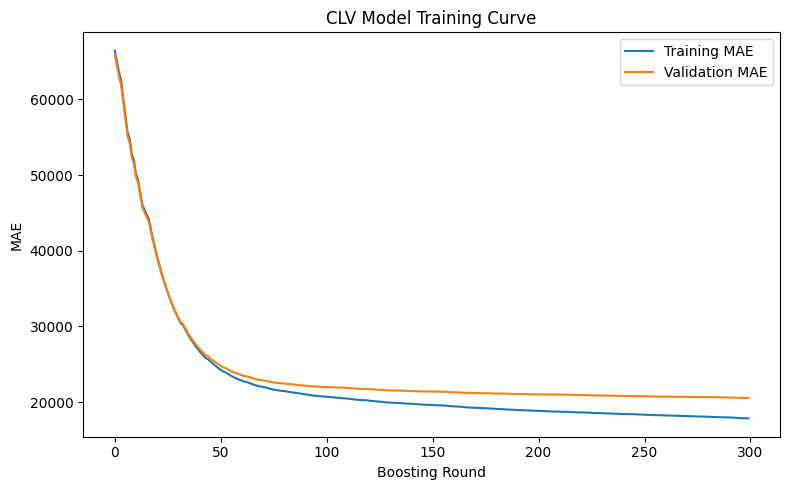

In [406]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt

# Use the latest payment date in the data as our stand-in for "today"
snapshot_date = df['Last Payment Date'].max()
#  How many months each loan has been running
df['Loan_Age_Months'] = (snapshot_date - df['Activation Date']).dt.days / 30.44
# # Make sure every loan counts as at least 1 month old, so brand-new loans don't get a broken value
df['Loan_Age_Months'] = df['Loan_Age_Months'].clip(lower=1)
# How much money has the loan actually earned per month, not just in total
df['Realized_Value_Rate'] = (df['Interest Paid'] + df['Fees Paid']) / df['Loan_Age_Months']

# List the client and loan details the model is allowed to learn from
feature_cols = [
    'Age Band (Client)',
    'Gender (Client)',
    'Completed Loan Cycles (Client)',
    'Deposits Balance (Client)',
    'Nature of business',
    'Loan Usage',
    'Loan usage Business',
    'Branch',
    'Product',
    'Loan Amount',
    'Interest Rate',
    'Number of Installments',
    'Loan_Age_Months',
]
target_col = 'Realized_Value_Rate'

model_df = df[feature_cols + [target_col]].copy()

# STEP 3: Train LightGBM CLV Regressor

categorical_cols = [
    'Age Band (Client)',
    'Gender (Client)',
    'Nature of business',
    'Loan Usage',
    'Loan usage Business',
    'Branch',
    'Product',
]
for col in categorical_cols:
    model_df[col] = model_df[col].astype('category')

X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameter tuning: test 20 random parameter combinations

param_dist = {
    'n_estimators': [100, 200, 300, 500, 800],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'max_depth': [4, 5, 6, 7, 8, -1],
    'num_leaves': [15, 31, 47, 63, 95],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

base_model = lgb.LGBMRegressor(objective='regression', random_state=42, verbose=-1)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train, categorical_feature=categorical_cols)

print("Best parameters found:", search.best_params_)
print("Best cross-validation R2:", search.best_score_)

# Show top 10 experiments, ranked
results_df = pd.DataFrame(search.cv_results_)[['params', 'mean_test_score', 'rank_test_score']]
results_df = results_df.sort_values('rank_test_score')
print(results_df.head(10).to_string())

# Train final model with the best parameters, tracking progress

best_params = search.best_params_
final_model = lgb.LGBMRegressor(objective='regression', random_state=42, verbose=-1, **best_params)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_names=['train', 'validation'],
    eval_metric='mae',
    categorical_feature=categorical_cols
)

y_pred = final_model.predict(X_test)
print("Final Test MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("Final Test R2:", round(r2_score(y_test, y_pred), 4))

# Training curve: shows the model improving over boosting rounds

results = final_model.evals_result_
plt.figure(figsize=(8, 5))
plt.plot(results['train']['l1'], label='Training MAE')
plt.plot(results['validation']['l1'], label='Validation MAE')
plt.xlabel('Boosting Round')
plt.ylabel('MAE')
plt.title('CLV Model Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

We used a method called Randomized Search, which tries out 20 different random combinations and checks how well each one performs. To make sure the results were trustworthy, each combination was tested using 3-fold cross-validation — meaning the training data was split into 3 parts, and each combination was trained and checked 3 separate times on different portions of the data before averaging the result. This gives a more reliable picture of how well a setting would actually generalize, rather than judging it on a single lucky or unlucky split.

Out of the 20 combinations tried, the best one found was: 300 trees, a learning rate of 0.05, trees limited to a depth of 4, and a few other supporting settings tuned alongside it. This combination scored an average R² of about 0.795 during cross-validation, meaning the model reliably explained close to 80% of the variation in client value across different slices of the training data. We then took this best combination and trained one final model on the full training set, then tested it on data it had never seen before. That final model reached a Test R² of 0.79 and a Test MAE of about 20,551.

To visually check whether the model was learning in a healthy way, we plotted a training curve. This chart tracks the model's error (MAE) after every additional tree it builds, called a "boosting round," shown separately for the training data and the untouched validation data. In the resulting chart, both lines drop sharply within the first 50 rounds and then flatten out and stay close together for the rest of training. This is exactly what you want to see: it means the model is genuinely learning useful patterns (the error is going down), and it isn't overfitting — if the training line kept dropping while the validation line went back up or stayed far above it, that would mean the model was just memorizing the training data instead of learning something that generalizes to new clients.

## Component 4 - Loan Limit Estimation

Same leakage-safe feature set as Component 2, minus `Loan Amount` (now the regression target) — the limit is recommended from client and loan-term characteristics, not from how the loan already played out.

In [407]:
limit_num_features = [f for f in num_features if f != 'Loan Amount']
limit_df = df[cat_features + limit_num_features + ['Loan Amount']].dropna().copy()

X_full_l = limit_df[cat_features + limit_num_features].copy()
y_full_l = limit_df['Loan Amount']

X_trainval_l, X_test_l, y_trainval_l, y_test_l = train_test_split(X_full_l, y_full_l, test_size=0.2, random_state=42)
X_train_l, X_val_l, y_train_l, y_val_l = train_test_split(X_trainval_l, y_trainval_l, test_size=0.25, random_state=42)

for c in cat_features:
    X_train_l[c] = X_train_l[c].astype('category')
    X_val_l[c] = X_val_l[c].astype('category')
    X_test_l[c] = X_test_l[c].astype('category')

In [408]:
def objective_limit(trial):
    from lightgbm import LGBMRegressor
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42, 'verbose': -1,
    }
    m = LGBMRegressor(**params)
    m.fit(X_train_l, y_train_l, categorical_feature=cat_features)
    from sklearn.metrics import r2_score
    return r2_score(y_val_l, m.predict(X_val_l))

study_limit = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_limit.optimize(objective_limit, n_trials=30)
print("Best val R2:", round(study_limit.best_value, 4))

Best val R2: 0.5966


In [409]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_params_l = dict(study_limit.best_params, random_state=42, verbose=-1)
limit_model = LGBMRegressor(**best_params_l)

X_trainval_l_enc = pd.concat([X_train_l, X_val_l])
y_trainval_l_enc = pd.concat([y_train_l, y_val_l])
for c in cat_features:
    X_trainval_l_enc[c] = X_trainval_l_enc[c].astype('category')

limit_model.fit(X_trainval_l_enc, y_trainval_l_enc, categorical_feature=cat_features)
pred_l = limit_model.predict(X_test_l)

mae = mean_absolute_error(y_test_l, pred_l)
print(f"Test MAE:  {mae:,.0f} ({mae/y_test_l.mean()*100:.1f}% of mean)")
print(f"Test RMSE: {mean_squared_error(y_test_l, pred_l)**0.5:,.0f}")
print(f"Test R2:   {r2_score(y_test_l, pred_l):.4f}")

Test MAE:  1,369,958 (42.1% of mean)
Test RMSE: 2,455,556
Test R2:   0.5333


## Component 5 - Fraud Detection - Unknown and New Patterns

In [410]:
df.columns.tolist()

['Branch',
 'Account ID',
 'Approval Date',
 'Activation Date',
 'First Repayment Date',
 'Last Payment Date',
 'Product',
 'Loan Amount',
 'Principal Balance',
 'Interest Balance',
 'Fee Balance',
 'Interest Accrued',
 'Penalty Balance',
 'Days In Arrears',
 'Principal Due',
 'Interest Due',
 'Fees Due',
 'Penalty Due',
 'Total Due',
 'Principal Paid',
 'Interest Paid',
 'Fees Paid',
 'Total Paid',
 'Number of Installments',
 'Account State',
 'Account Sub-State',
 'Last Payment Amount',
 'Expected Maturity Date',
 'Gender (Client)',
 'Loan Usage',
 'Was Refinanced',
 'Days Late',
 'Risk Level',
 'Created (Client)',
 'Interest Rate',
 'Loan usage Business',
 'Completed Loan Cycles (Client)',
 'Deposits Balance (Client)',
 'Arrears Tolerance Period',
 'Environmental & Social Risk',
 'Age Band (Client)',
 'Nature of business',
 'Total Balance',
 'Has Made Last Payment',
 'Loan_Cycle_Group',
 'Days Since Last Payment',
 'Loan Frequency',
 'Repayment Ratio',
 'Financial DNA Segment',
 'Lo

In [411]:
from sklearn.ensemble import IsolationForest
anomaly_cols = [
    "Loan Amount",
    "Interest Rate",
    "Days In Arrears",
    "Total Balance",
    "Total Paid",
    "Total Due",
    "Principal Balance",
    "Interest Balance",
    "Penalty Balance"
]

anomaly_data = df[anomaly_cols].dropna().copy()

anomaly_data.head()

,Loan Amount,Interest Rate,Days In Arrears,Total Balance,Total Paid,Total Due,Principal Balance,Interest Balance,Penalty Balance
0,174800,3.5000,0,167700,148100,0,167700,0,0
1,3060000,61.8069,2724,6055300,3889600,6055400,2716200,3339100,0
2,4560000,61.8069,2356,8009300,6810600,8009400,3881300,4128000,0
3,1540000,61.8069,1733,293300,4711600,293400,269600,23700,0
4,1480000,61.8069,1885,652400,4157600,652400,526100,126300,0


In [412]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso_forest.fit(anomaly_data)

IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

In [413]:
anomaly_data["anomaly_score"] = iso_forest.decision_function(anomaly_data)

anomaly_data["anomaly_flag"] = iso_forest.predict(anomaly_data[anomaly_cols])

anomaly_data.head()

,Loan Amount,Interest Rate,Days In Arrears,Total Balance,Total Paid,Total Due,Principal Balance,Interest Balance,Penalty Balance,anomaly_score,anomaly_flag
0,174800,3.5000,0,167700,148100,0,167700,0,0,0.196707,1
1,3060000,61.8069,2724,6055300,3889600,6055400,2716200,3339100,0,-0.201370,-1
2,4560000,61.8069,2356,8009300,6810600,8009400,3881300,4128000,0,-0.217440,-1
3,1540000,61.8069,1733,293300,4711600,293400,269600,23700,0,-0.073438,-1
4,1480000,61.8069,1885,652400,4157600,652400,526100,126300,0,-0.084299,-1


In [414]:
anomaly_data["anomaly_flag"].value_counts()

anomaly_flag
 1    22566
-1     1188
Name: count, dtype: int64

In [415]:
anomaly_percentage = (
    (anomaly_data["anomaly_flag"] == -1).mean() * 100
)

print(f"Anomaly rate: {anomaly_percentage:.2f}%")

Anomaly rate: 5.00%


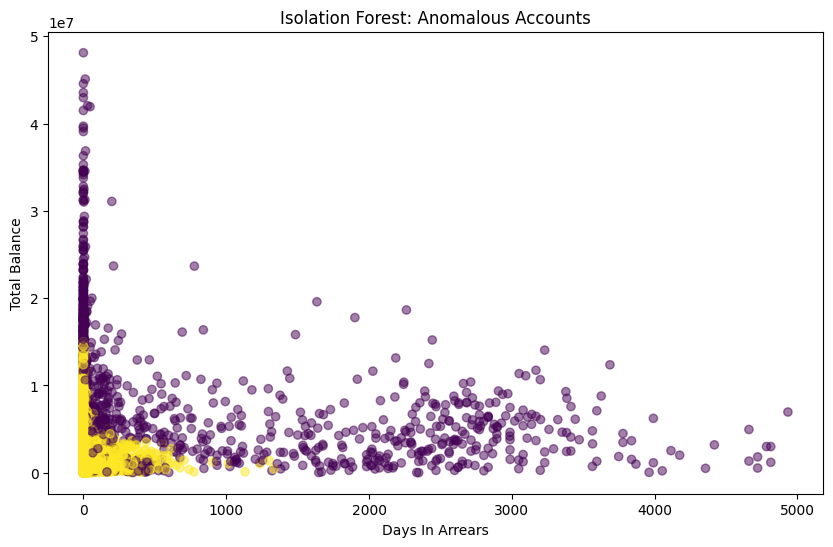

In [416]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    anomaly_data["Days In Arrears"],
    anomaly_data["Total Balance"],
    c=anomaly_data["anomaly_flag"],
    alpha=0.5
)

plt.xlabel("Days In Arrears")
plt.ylabel("Total Balance")
plt.title("Isolation Forest: Anomalous Accounts")
plt.show()

Isolation Forest: Anomalous Accounts
The scatter plot shows the accounts identified by the Isolation Forest model based on Days in Arrears and Total Balance. The model separates normal accounts from unusual observations based on their financial characteristics. The highlighted points represent accounts flagged as anomalies, which may require further investigation due to unusually high arrears, balances, or other financial patterns.

Two distinct anomaly signatures emerge rather than one uniform pattern:

Large, current loans — flagged accounts with low Days in Arrears but unusually high Total Balance, standing out on loan size alone since most of the portfolio holds much smaller balances.
Long-running arrears — flagged accounts trailing out to very high Days in Arrears (some past 4,000 days) regardless of balance size, isolated by how rare that arrears length is on its own.
The dense cluster of normal accounts sits tightly at low balance and low arrears, showing the model is flagging departures from typical portfolio behaviour rather than the ordinary bulk of the portfolio.

Key takeaway: The model identified 1,188 anomalous accounts out of 23,754 accounts, representing approximately 5.0% of the dataset, split between these two distinct behavioural patterns rather than a single type of outlier.

In [417]:
anomalies = anomaly_data[anomaly_data["anomaly_flag"] == -1]

anomalies.head()

,Loan Amount,Interest Rate,Days In Arrears,Total Balance,Total Paid,Total Due,Principal Balance,Interest Balance,Penalty Balance,anomaly_score,anomaly_flag
1,3060000,61.8069,2724,6055300,3889600,6055400,2716200,3339100,0,-0.201370,-1
2,4560000,61.8069,2356,8009300,6810600,8009400,3881300,4128000,0,-0.217440,-1
3,1540000,61.8069,1733,293300,4711600,293400,269600,23700,0,-0.073438,-1
4,1480000,61.8069,1885,652400,4157600,652400,526100,126300,0,-0.084299,-1
5,2840000,61.8069,2720,5482500,3747600,5482400,2497000,2985500,0,-0.189300,-1


In [418]:
anomaly_data.groupby("anomaly_flag")[anomaly_cols].mean()

,Loan Amount,Interest Rate,Days In Arrears,Total Balance,Total Paid,Total Due,Principal Balance,Interest Balance,Penalty Balance
anomaly_flag,,,,,,,,,
-1,9.535701e+06,23.656821,750.447811,8.735112e+06,7.434813e+06,2.981884e+06,7.553934e+06,929926.010101,43831.649832
1,2.927200e+06,6.178650,6.357352,2.509255e+06,2.173760e+06,7.963082e+04,2.481468e+06,20981.077728,294.731011


The comparison shows clear differences between accounts classified as normal and those flagged as anomalies by the Isolation Forest model.

Anomalous accounts have substantially higher average loan amounts, interest rates, total balances, and amounts due. They also show significantly higher levels of arrears, with an average of approximately 750 days compared with about 6 days for normal accounts. Interest and penalty balances are also considerably higher among the anomalous accounts.

These results suggest that the model is identifying accounts with unusually high financial exposure and repayment difficulty compared with the typical portfolio. The strongest difference is observed in Days In Arrears, while the higher balances, interest, and penalties provide additional evidence of unusual repayment behaviour.

These accounts should therefore be treated as priority cases for further investigation, rather than being automatically classified as fraudulen

In [419]:
anomaly_results = df.loc[anomaly_data.index].copy()

anomaly_results["anomaly_score"] = anomaly_data["anomaly_score"]
anomaly_results["anomaly_flag"] = anomaly_data["anomaly_flag"]

anomaly_results.head()

,Branch,Account ID,Approval Date,Activation Date,First Repayment Date,Last Payment Date,Product,Loan Amount,Principal Balance,Interest Balance,...,Loan_Cycle_Group,Days Since Last Payment,Loan Frequency,Repayment Ratio,Financial DNA Segment,Loan Age Days,Loan_Age_Months,Realized_Value_Rate,anomaly_score,anomaly_flag
0,Branch-002,ACC-8413677F5127,2025-01-05,2025-01-05,2025-02-04,2026-09-27,Product-044,174800,167700,0,...,1 or less,51.0,0,1.000000,Reliable Payer,681,22.371879,6302.555066,0.196707,1
1,Branch-008,ACC-02AAD5CBBFD3,2017-05-08,2017-05-08,2017-05-19,2026-09-16,Product-026,3060000,2716200,3339100,...,1 or less,62.0,0,0.391111,Chronic Defaulter,3480,114.323259,31016.435632,-0.201370,-1
2,Branch-068,ACC-C3EA6CE82D4F,2017-07-29,2017-07-28,2017-09-22,2026-05-17,Product-026,4560000,3881300,4128000,...,1 or less,184.0,1,0.459555,Chronic Defaulter,3398,111.662286,54915.586937,-0.217440,-1
3,Branch-008,ACC-BC262E2C2C28,2017-01-13,2016-12-06,2017-01-03,2026-04-18,Product-026,1540000,269600,23700,...,1 or less,213.0,0,0.941379,Chronic Defaulter,3595,119.349540,28833.793559,-0.073438,-1
4,Branch-016,ACC-B479775F2524,2017-02-08,2017-01-03,2017-01-31,2026-06-15,Product-026,1480000,526100,126300,...,1 or less,155.0,0,0.864366,Chronic Defaulter,3569,118.429698,27051.491817,-0.084299,-1


In [420]:
anomaly_summary = anomaly_results[
    anomaly_results["anomaly_flag"] == -1
][[
    "Account ID",
    "Branch",
    "Loan Amount",
    "Days In Arrears",
    "Total Balance",
    "Interest Rate",
    "Risk Level",
    "Account State",
    "anomaly_score"
]]

anomaly_summary.head(10)

,Account ID,Branch,Loan Amount,Days In Arrears,Total Balance,Interest Rate,Risk Level,Account State,anomaly_score
1,ACC-02AAD5CBBFD3,Branch-008,3060000,2724,6055300,61.8069,>180 Days,In Arrears,-0.201370
2,ACC-C3EA6CE82D4F,Branch-068,4560000,2356,8009300,61.8069,>180 Days,In Arrears,-0.217440
3,ACC-BC262E2C2C28,Branch-008,1540000,1733,293300,61.8069,>180 Days,In Arrears,-0.073438
4,ACC-B479775F2524,Branch-016,1480000,1885,652400,61.8069,>180 Days,In Arrears,-0.084299
5,ACC-6B64E9CB8B3E,Branch-007,2840000,2720,5482500,61.8069,>180 Days,In Arrears,-0.189300
6,ACC-493795F7FCD0,Branch-016,2450000,3472,3784300,61.8100,>180 Days,In Arrears,-0.161430
7,ACC-E35A5AEF5F35,Branch-013,2500000,3991,6232200,61.8100,>180 Days,In Arrears,-0.202594
8,ACC-F01D36D33099,Branch-063,4700000,2622,603800,61.8100,>180 Days,In Arrears,-0.145429
9,ACC-FFF356C2A10F,Branch-067,2000000,2073,1388000,61.8100,>180 Days,In Arrears,-0.107326
10,ACC-CF030E91F752,Branch-065,3100000,2834,6349400,61.8100,>180 Days,In Arrears,-0.203891


In [421]:
anomaly_results[anomaly_results["anomaly_flag"] == -1]["Risk Level"].value_counts()

Risk Level
>180 Days      499
Current        295
1-30 days      223
91-180 Days     85
31-60 Days      50
61-90 Days      36
Name: count, dtype: int64

Anomaly Distribution by Risk Level
The distribution of anomalies shows that the Isolation Forest model identified unusual accounts across all existing risk categories.

The largest number of anomalies occurred among accounts classified as >180 Days, with 499 flagged accounts. However, the model also identified 295 Current accounts as anomalous, followed by 223 accounts in the 1–30 days category.

This is an important finding because it shows that the anomaly detection model is not simply reproducing the existing Risk Level classification. Some accounts considered Current under the existing risk framework still display unusual combinations of financial and repayment characteristics.

The results suggest that Isolation Forest can provide an additional layer of monitoring by highlighting unusual behaviour that may not be immediately visible through existing risk categories. These flagged accounts would require further investigation rather than being automatically treated as fraudulent.

In [422]:
anomaly_results[anomaly_results["anomaly_flag"] == -1]["Branch"].value_counts().head(10)

Branch
Branch-022    146
Branch-023     96
Branch-031     67
Branch-008     65
Branch-055     59
Branch-032     49
Branch-065     46
Branch-021     41
Branch-067     33
Branch-006     28
Name: count, dtype: int64

Anomaly Distribution by Branch
The anomaly detection results show that flagged accounts are not evenly distributed across branches.

Branch-022 recorded the highest number of anomalous accounts with 146, followed by Branch-023 with 96 and Branch-031 with 67.

This concentration suggests that certain branches may warrant closer investigation into their portfolio characteristics and repayment patterns. However, the number of anomalies alone does not indicate that a branch has higher risk, since branch sizes may differ.

A branch-level anomaly rate would therefore provide a more meaningful comparison by considering the number of anomalous accounts relative to the total number of accounts within each branch.

In [423]:
branch_rates = (
    anomaly_results.groupby("Branch")
    .agg(total_accounts=("anomaly_flag", "count"),
        anomalous_accounts=("anomaly_flag", lambda x: (x == -1).sum()))
)

branch_rates["anomaly_rate"] = (branch_rates["anomalous_accounts"] / branch_rates["total_accounts"] * 100)

branch_rates.sort_values("anomaly_rate", ascending=False).head(10)

,total_accounts,anomalous_accounts,anomaly_rate
Branch,,,
Branch-024,64,12,18.750000
Branch-041,53,8,15.094340
Branch-028,177,24,13.559322
Branch-026,76,10,13.157895
Branch-022,1204,146,12.126246
Branch-039,75,9,12.000000
Branch-032,433,49,11.316397
Branch-031,593,67,11.298482
Branch-020,18,2,11.111111


Anomaly Rate by Branch
The branch-level analysis shows that anomalous accounts are distributed unevenly across the portfolio. Branch-024 has the highest anomaly rate at 18.75%, with 12 of its 64 accounts flagged as anomalous. This is followed by Branch-041 at 15.09% and Branch-028 at 13.56%.

Branch-022 recorded the largest number of anomalous accounts overall (146), but its anomaly rate is 12.13% because it also has a much larger number of total accounts. This distinction shows why anomaly rates provide a more meaningful comparison across branches than anomaly counts alone.

Branches with higher anomaly rates may warrant closer investigation into their portfolio characteristics and repayment patterns. However, a higher anomaly rate does not by itself indicate fraud or poor branch performance and should be investigated alongside other business factors.

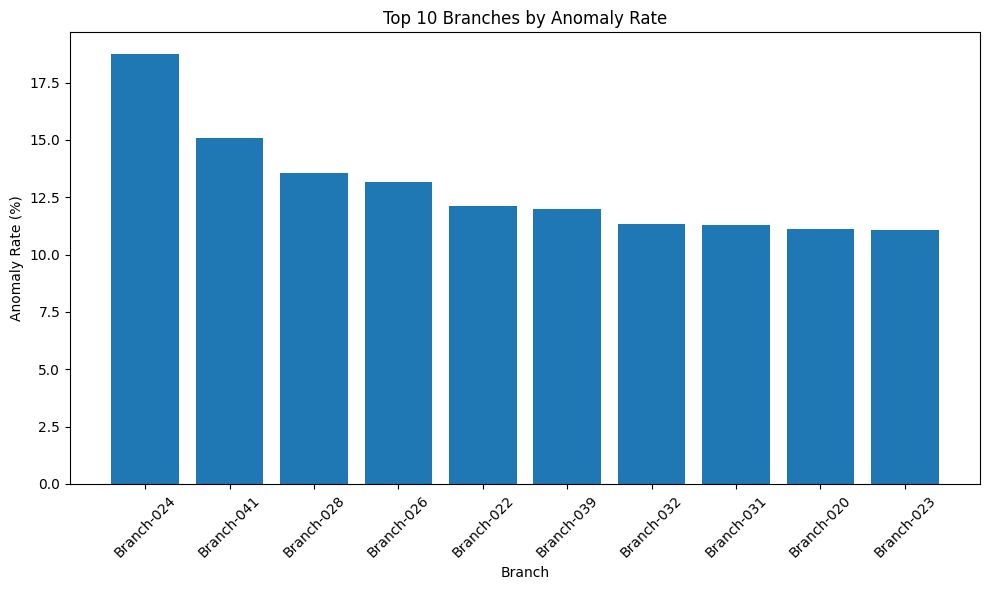

In [424]:
top_branches = branch_rates.sort_values(
    "anomaly_rate", ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_branches.index,
    top_branches["anomaly_rate"]
)

plt.xlabel("Branch")
plt.ylabel("Anomaly Rate (%)")
plt.title("Top 10 Branches by Anomaly Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Branches with the Highest Anomaly Rates
The chart shows the top 10 branches with the highest proportion of accounts flagged as anomalies by the Isolation Forest model.

Branch-024 has the highest anomaly rate at 18.75%, followed by Branch-041 at 15.09% and Branch-028 at 13.56%. Branch-022, despite having the highest number of anomalous accounts overall, has a lower anomaly rate of 12.13% because it has a larger total number of accounts.

These results highlight branches where a relatively high proportion of accounts display unusual financial patterns. These branches may warrant further investigation into portfolio composition, repayment behaviour, and other underlying factors. However, the anomaly rate should be treated as a screening measure rather than evidence of fraud or poor branch performance.

Isolation Forest Evaluation
Since Isolation Forest is an unsupervised anomaly detection algorithm, confirmed fraud labels were not available for calculating conventional classification metrics such as precision, recall, F1-score, or ROC-AUC.

The model was therefore evaluated using:

Anomaly rate: the proportion of accounts identified as unusual.
Anomaly score distribution: comparison of anomaly scores between normal and flagged observations.
Feature comparison: comparison of financial and repayment characteristics between normal and anomalous accounts.
Risk-level distribution: examination of how detected anomalies are distributed across existing risk categories.
Visual analysis: inspection of the relationship between key financial variables and anomaly flags.
The model identified 1,188 anomalous accounts out of 23,754 observations, representing approximately 5% of the dataset.

The evaluation showed that anomalous accounts generally had higher loan amounts, balances, interest-related values, and days in arrears than normal accounts. This indicates that the model is identifying observations with unusual financial and repayment characteristics.

The anomaly results should be interpreted as a prioritisation mechanism for further investigation rather than definitive evidence of fraud. An account being classified as an anomaly does not necessarily mean that fraud has occurred.

SHAP Explainability
SHAP (SHapley Additive exPlanations) was used to improve the interpretability of the Isolation Forest anomaly detection model.

While Isolation Forest identifies accounts that differ from the normal population, SHAP helps explain which features contributed most to an account's anomaly score. This is important for the Financial DNA system because flagged accounts should be traceable to the financial and repayment characteristics that contributed to the model's decision.

The SHAP analysis is used at two levels:

Global explanation: identifies the features that contribute most strongly to anomaly detection across the dataset.
Individual explanation: shows the features contributing to the anomaly score of a specific flagged account.
SHAP explanations should be interpreted as model-based contributions rather than proof that a particular feature caused fraud. A flagged account still requires further investigation.

In [425]:
import shap

explainer = shap.TreeExplainer(iso_forest)

shap_values = explainer.shap_values(anomaly_data[anomaly_cols])

assert len(shap_values) == len(anomaly_data), \
    "SHAP values and anomaly_data are misaligned."

In [426]:
shap_values.shape

(23754, 9)

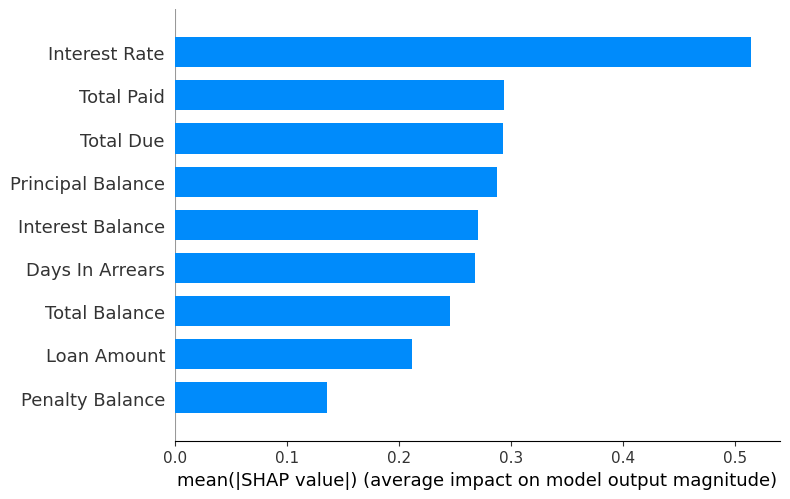

In [427]:
#Which features matter most overall
shap.summary_plot(
    shap_values,
    anomaly_data[anomaly_cols],
    plot_type="bar"
)

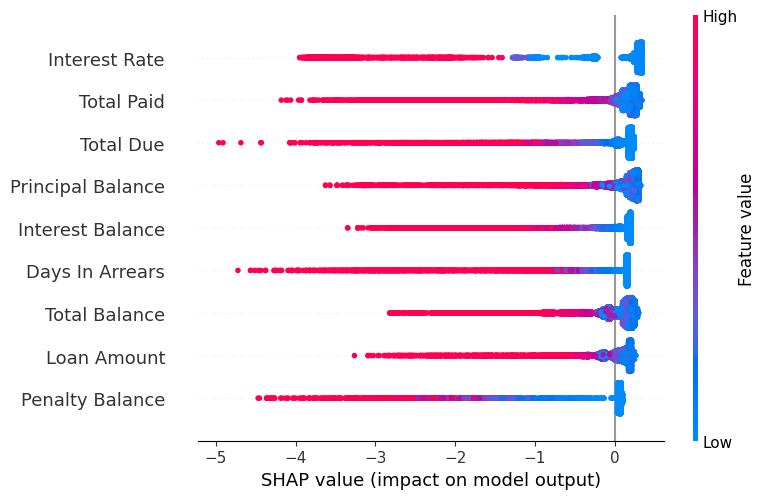

In [428]:
#How do high and low values of those features influence the model
shap.summary_plot(
    shap_values,
    anomaly_data[anomaly_cols]
)

SHAP Global Explanation
The SHAP summary plots show how each feature contributes to an account's anomaly score across the dataset. Since the Isolation Forest assigns higher decision scores to more normal accounts and lower (more negative) scores to more anomalous accounts, a negative SHAP contribution pushes an account toward a more anomalous decision, while a positive contribution pushes it toward a more normal decision.

Across the main financial and repayment features: Interest Rate, Total Paid, Total Due, Principal Balance, Interest Balance, Days In Arrears, Total Balance, and Loan Amount, higher feature values (shown in red) are predominantly associated with negative SHAP values. This indicates that larger values of these variables tend to push observations toward a more anomalous model output. Lower feature values (shown in blue) are generally clustered closer to zero and therefore have less influence on the model output for many observations.

Interest Rate is the strongest overall driver of the anomaly scores, with a mean absolute SHAP value of approximately 0.51. This is notably higher than the next group of features, including Total Paid, Total Due, Principal Balance, Interest Balance, Days In Arrears, and Total Balance, which have mean absolute SHAP values of approximately 0.24–0.29.

Loan Amount and Penalty Balance have lower average SHAP importance. Penalty Balance also shows less consistent directional behaviour, with high values appearing across a wider range of SHAP values.

The SHAP results provide a different perspective from the earlier comparison of mean values between normal and anomalous accounts. For example, Days In Arrears showed a particularly large difference between anomalous and normal accounts in the earlier analysis, while Interest Rate had the highest average SHAP importance. These findings are not contradictory: the mean comparison describes differences in the underlying feature values, whereas SHAP measures each feature's contribution to the model output. The two analyses therefore provide complementary views of the anomaly patte

In [429]:
anomalous_indices = anomaly_data.index[anomaly_data["anomaly_flag"] == -1]
selected_index = anomalous_indices[0]

print("Selected anomalous account index:", selected_index)

Selected anomalous account index: 1


In [430]:
# Select the most extreme anomalous account (lowest anomaly score = most anomalous)
#.idxmin : index of the minimum value
selected_index = anomaly_data[anomaly_data["anomaly_flag"] == -1]["anomaly_score"].idxmin()
print("Most anomalous account index:", selected_index)
print("Anomaly score:", anomaly_data.loc[selected_index, "anomaly_score"])

Most anomalous account index: 9237
Anomaly score: -0.28339400648637136


In [431]:
# Get the SHAP values for the selected anomalous account
selected_shap_values = shap_values[anomaly_data.index.get_loc(selected_index)]
selected_shap_values

array([-1.13837612,  0.08256971, -0.85312484, -1.37227483, -0.4288431 ,
       -2.41178334, -1.52059916, -1.90924651, -2.22920612])

In [432]:
individual_shap = pd.DataFrame({
    "Feature": anomaly_cols,
    "SHAP Value": selected_shap_values
})

individual_shap.sort_values("SHAP Value",key=abs,ascending=False)

,Feature,SHAP Value
5,Total Due,-2.411783
8,Penalty Balance,-2.229206
7,Interest Balance,-1.909247
6,Principal Balance,-1.520599
3,Total Balance,-1.372275
0,Loan Amount,-1.138376
2,Days In Arrears,-0.853125
4,Total Paid,-0.428843
1,Interest Rate,0.082570


SHAP Individual Explanation
For the selected anomalous account, SHAP values show which features contributed most to its specific anomaly flag above

Nearly every feature contributed negatively, pushing this account toward a more anomalous model output, with Total Due, Penalty Balance, and Interest Balance having the strongest individual contributions. Interest Rate — the leading feature in the global explanation — contributed only marginally here and in the opposite direction, showing that the factors contributing to an anomaly can differ from one account to another.

For this account, the strongest model contributions came from Total Due, Penalty Balance, Interest Balance, and Principal Balance, indicating that the account's financial and repayment characteristics were important in its anomaly classification.

This case-level explanation allows a flagged account to be traced back to specific financial characteristics that influenced the model's decision, supporting the explainability and traceability requirements of the Financial DNA system.

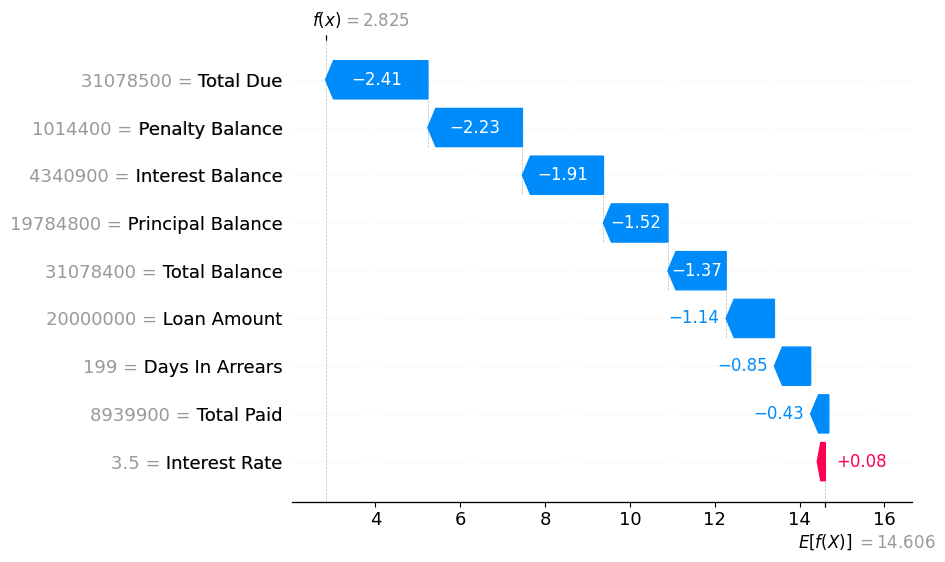

In [433]:
# Confirm that SHAP values and anomaly_data are aligned
assert len(shap_values) == len(anomaly_data), \
    "SHAP values and anomaly_data are misaligned."

# Select the most anomalous account
selected_index = anomaly_data["anomaly_score"].idxmin()

# Get the row position corresponding to the selected account
row_position = anomaly_data.index.get_loc(selected_index)

# Create the SHAP explanation for the selected account
explanation = shap.Explanation(
    values=shap_values[row_position],
    base_values=explainer.expected_value,
    data=anomaly_data.loc[selected_index, anomaly_cols].values,
    feature_names=anomaly_cols
)

# Display the waterfall plot
shap.plots.waterfall(
    explanation,
    max_display=len(anomaly_cols)
)

SHAP Individual Explanation — Waterfall Plot
The waterfall plot traces how the selected account's decision score moves from the dataset's average expected value, E[f(X)] = 14.606, down to its actual score, f(x) = 2.825, feature by feature.

The selected account has a Loan Amount of 20,000,000, a Total Due of 31,078,500, and a Total Balance of 31,078,400. Its Total Paid is 8,939,900, compared with the Total Due of 31,078,500. The account also has a Penalty Balance of 1,014,400 and 199 Days In Arrears.

Total Due (-2.41) and Penalty Balance (-2.23) are the largest individual contributors to the account's anomaly score, followed by Interest Balance (-1.91) and Principal Balance (-1.52). By contrast, the Interest Rate is 3.5% and contributes only marginally in the positive direction (+0.08), slightly moving the model output toward a more normal observation.

This account illustrates a specific pattern behind an anomaly flag: a large loan exposure combined with substantial outstanding balances, amounts due, and penalty accumulation. The anomaly is therefore influenced by several financial and repayment characteristics rather than being driven primarily by the interest rate.

This case-level SHAP explanation provides traceability from the model output back to the specific account characteristics that influenced the anomaly decision. However, the explanation describes the behaviour of the model and does not establish that the account is fraudulent. Further investigation would be required to determine the underlying reason for the unusual account characteristics.

In [434]:
import joblib

joblib.dump(iso_forest, "isolation_forest_model.pkl")

['isolation_forest_model.pkl']

Business Recommendations from Anomaly Detection
The Isolation Forest model identified accounts with unusual combinations of financial and repayment characteristics. The results can be used as an additional screening tool to support portfolio monitoring and credit management.

Based on the findings, the following actions are recommended:

Prioritise anomalous accounts for review

The 1,188 accounts flagged by the model should be reviewed based on their loan balances, arrears, repayment history, and other relevant account characteristics. The anomaly flag should support investigation rather than automatically classifying an account as fraudulent.

Strengthen monitoring of long-term arrears

Accounts with exceptionally high Days in Arrears should receive closer attention, particularly where they also have high outstanding balances or interest balances. These accounts may represent significant portfolio exposure.

Investigate anomalous current accounts

The model also identified accounts classified as Current under the existing risk framework. These accounts demonstrate unusual combinations of financial characteristics and may benefit from additional monitoring even though they are not currently classified as high risk.

Review branches with high anomaly rates

Branches with relatively high anomaly rates, such as Branch-024 and Branch-041, could be reviewed to understand whether differences in customer profiles, portfolio composition, lending practices, or repayment behaviour contribute to the higher concentration of anomalies.

Use anomaly detection alongside existing risk classifications

Isolation Forest should be used as a complementary monitoring tool rather than a replacement for the existing Risk Level classification. Combining both approaches can help identify unusual accounts that may not be captured by conventional risk categories.

Use SHAP explanations to guide investigation priorities

SHAP provides both portfolio-level and account-level insight into the factors contributing to anomaly scores. At the global level, Interest Rate was the strongest contributor to anomaly scores, while for the selected anomalous account, Total Due and Penalty Balance were among the strongest individual contributors. Investigators can use these per-account explanations to focus their review — for example, prioritising accounts where large amounts due and high penalty balances are contributing strongly to the anomaly score, rather than reviewing all 1,188 flagged accounts with the same level of scrutiny.

Key Takeaway
The Isolation Forest model, combined with SHAP explainability, provides an additional layer of portfolio monitoring by identifying unusual financial and repayment patterns and clarifying which specific factors contribute to each anomaly. Its greatest value is in prioritising accounts and branches for further investigation with clear model-based justification, allowing the business to focus attention on cases that differ substantially from typical portfolio behaviour.

## Component 6 - SHAP Explainability

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


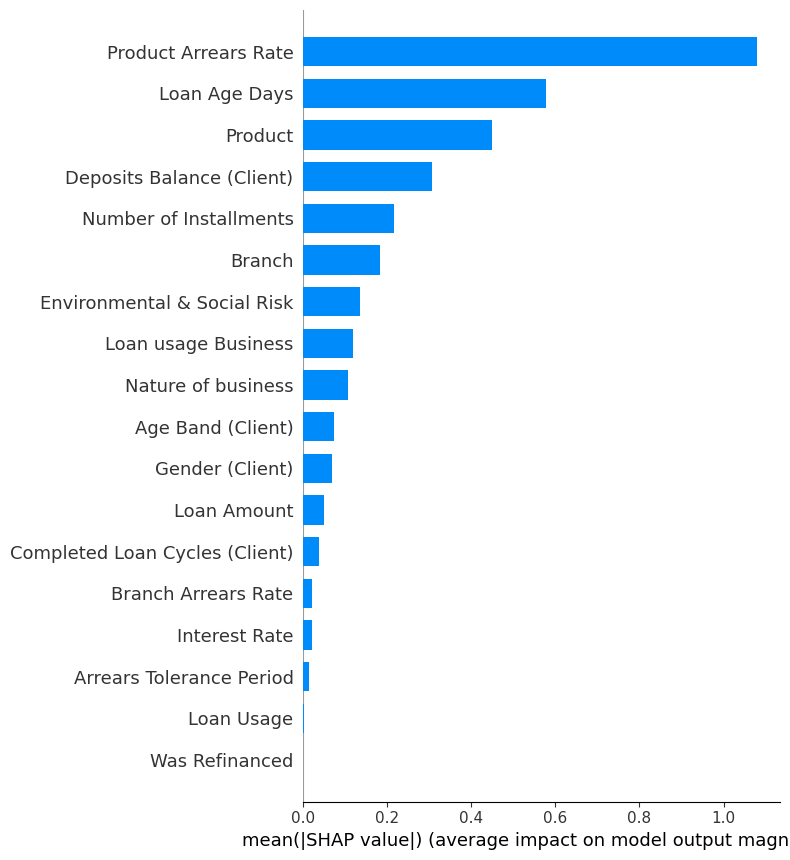

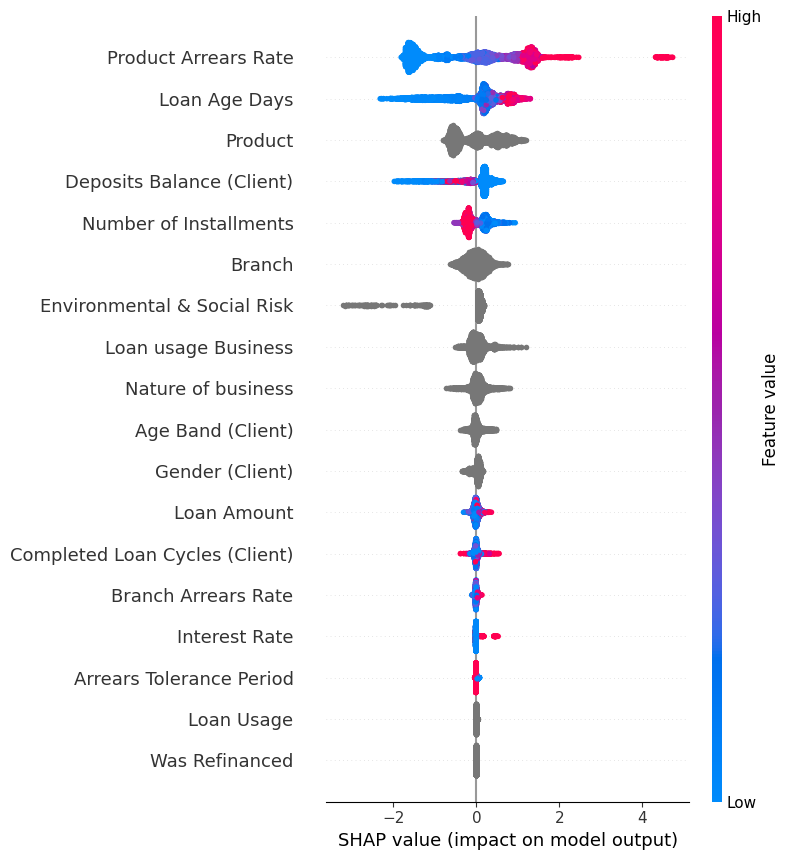

Selected highest-risk account index: 111  risk score: 0.9968


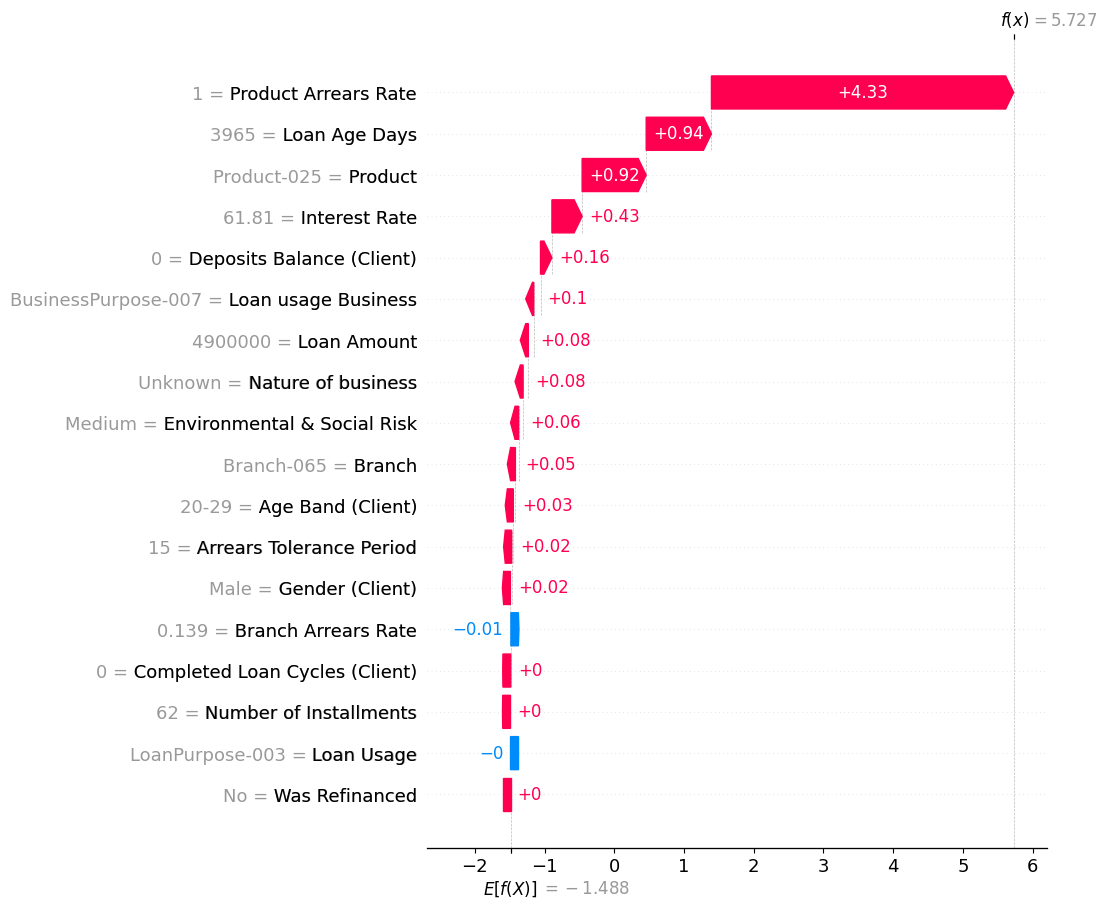

In [435]:
import numpy as np
import pandas as pd
import shap

# Risk model (classifier)
risk_explainer = shap.TreeExplainer(risk_model)
risk_shap_values = risk_explainer.shap_values(risk_X_test)
risk_shap_for_class1 = risk_shap_values[1] if isinstance(risk_shap_values, list) else risk_shap_values

shap.summary_plot(risk_shap_for_class1, risk_X_test, plot_type="bar")
shap.summary_plot(risk_shap_for_class1, risk_X_test)

# Individual client waterfall: the client the model is most confident is high-risk
risk_test_proba = risk_model.predict_proba(risk_X_test)[:, 1]
selected_position = int(np.argmax(risk_test_proba))
selected_index = risk_X_test.index[selected_position]
print("Selected highest-risk account index:", selected_index,
      " risk score:", round(risk_test_proba[selected_position], 4))

individual_shap_risk = pd.DataFrame({
    "Feature": risk_feature_cols,
    "SHAP Value": risk_shap_for_class1[selected_position]
})
individual_shap_risk.sort_values("SHAP Value", key=abs, ascending=False)

risk_base_value = risk_explainer.expected_value[1] if isinstance(risk_explainer.expected_value, list) else risk_explainer.expected_value
risk_explanation = shap.Explanation(
    values=risk_shap_for_class1[selected_position],
    base_values=risk_base_value,
    data=risk_X_test.iloc[selected_position].values,
    feature_names=risk_feature_cols
)
shap.plots.waterfall(risk_explanation, max_display=len(risk_feature_cols))

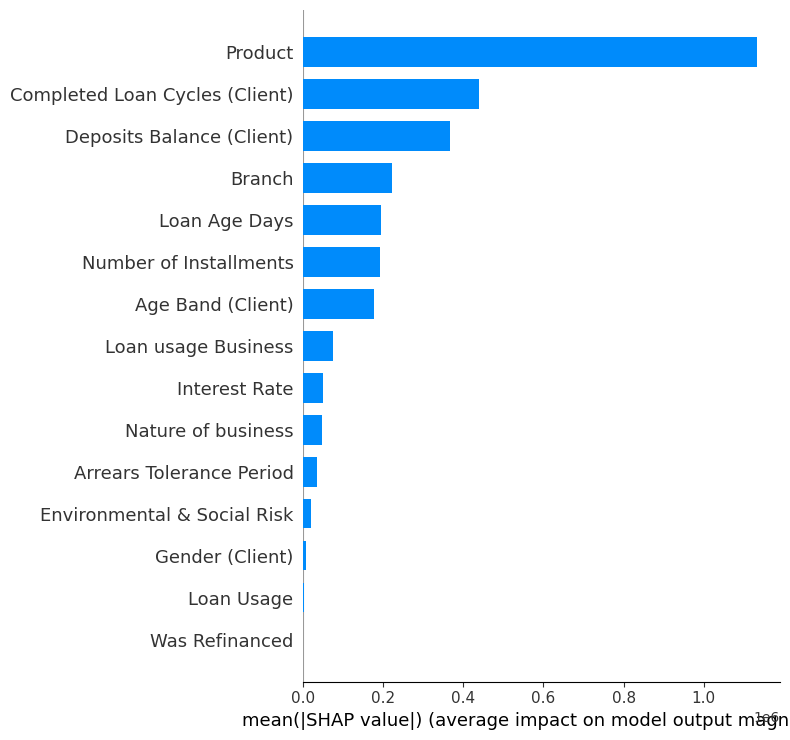

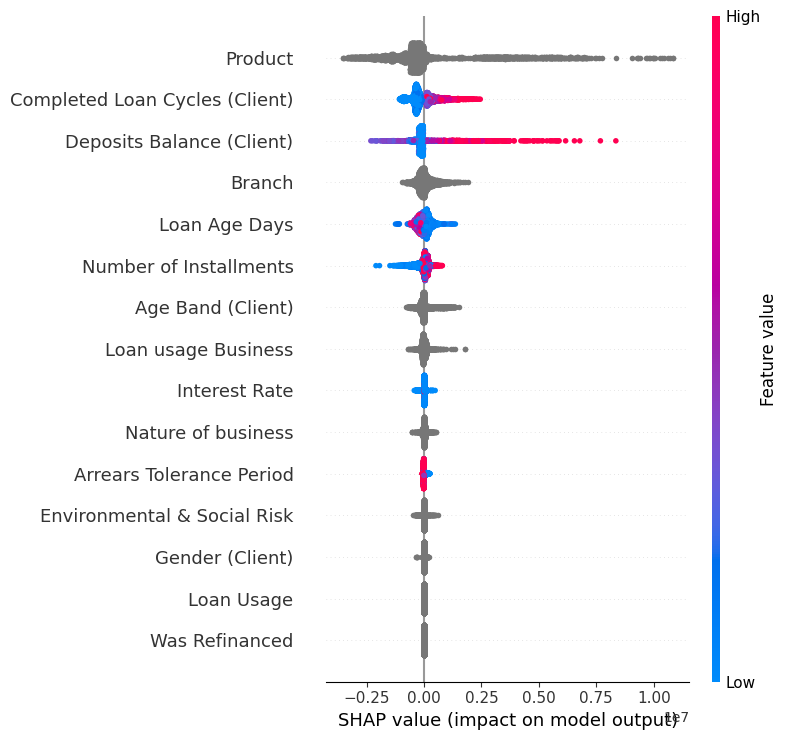

Selected largest-recommended-limit account index: 9165  recommended limit: 21039619.49


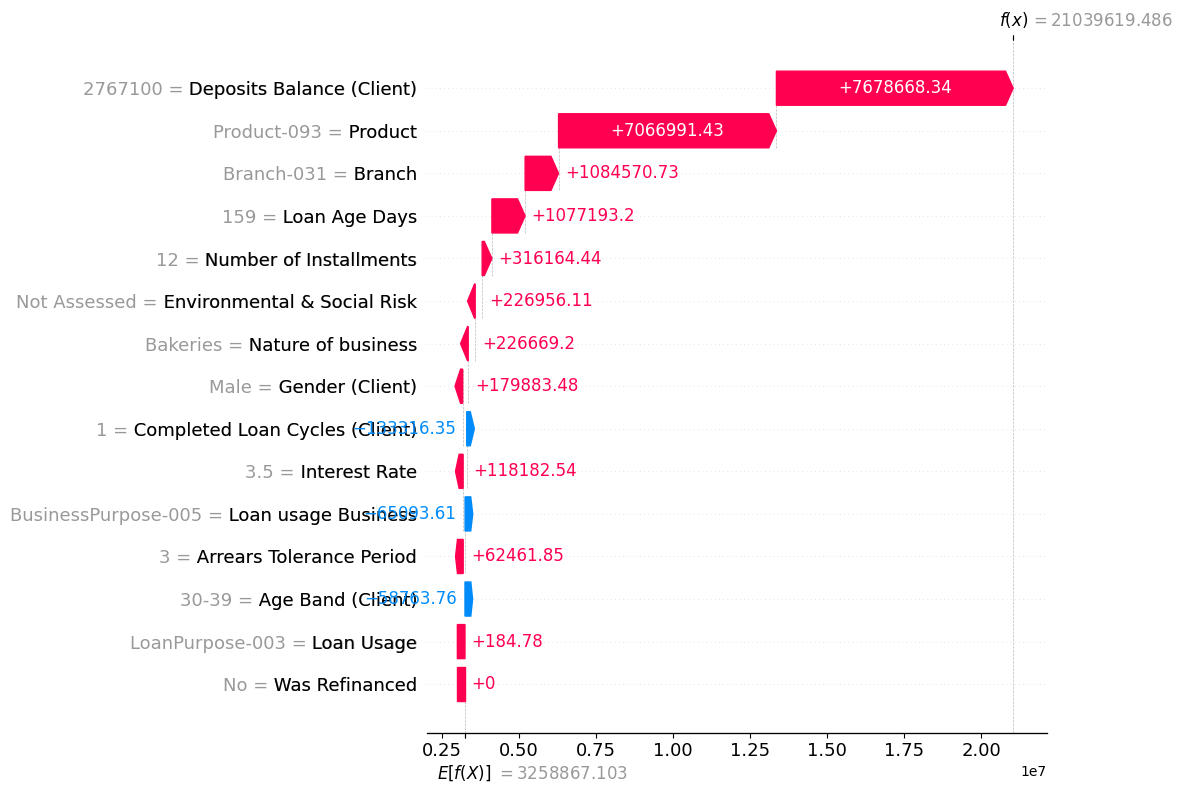

In [436]:
# Loan Limit model (regressor)  -- X_test_l is untouched, no collision
limit_explainer = shap.TreeExplainer(limit_model)
limit_shap_values = limit_explainer.shap_values(X_test_l)

shap.summary_plot(limit_shap_values, X_test_l, plot_type="bar")
shap.summary_plot(limit_shap_values, X_test_l)

#Individual client waterfall: the client with the largest recommended loan limit
limit_predictions = limit_model.predict(X_test_l)
selected_position = int(np.argmax(limit_predictions))
selected_index = X_test_l.index[selected_position]
print("Selected largest-recommended-limit account index:", selected_index,
      " recommended limit:", round(limit_predictions[selected_position], 2))

limit_feature_cols = list(X_test_l.columns)
individual_shap_limit = pd.DataFrame({
    "Feature": limit_feature_cols,
    "SHAP Value": limit_shap_values[selected_position]
})
individual_shap_limit.sort_values("SHAP Value", key=abs, ascending=False)

limit_explanation = shap.Explanation(
    values=limit_shap_values[selected_position],
    base_values=limit_explainer.expected_value,
    data=X_test_l.iloc[selected_position].values,
    feature_names=limit_feature_cols
)
shap.plots.waterfall(limit_explanation, max_display=len(limit_feature_cols))

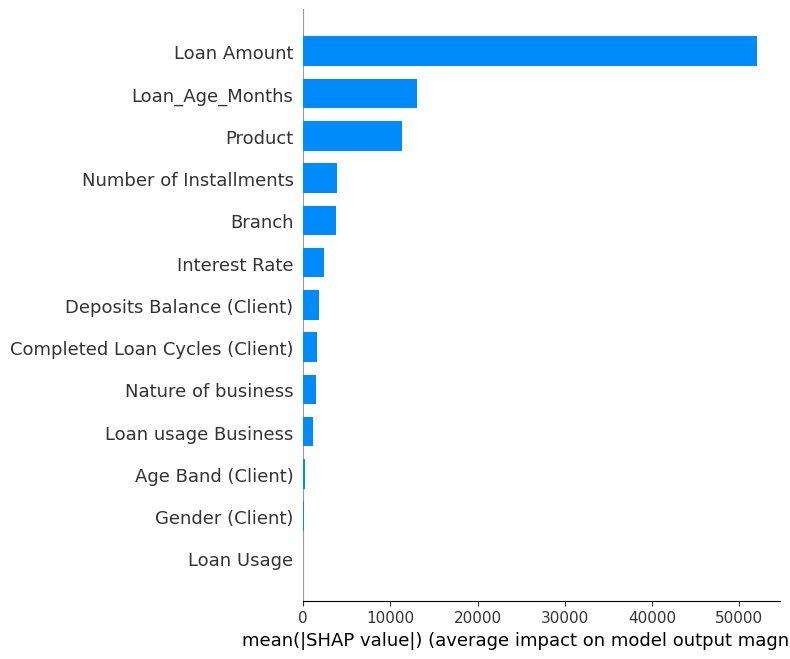

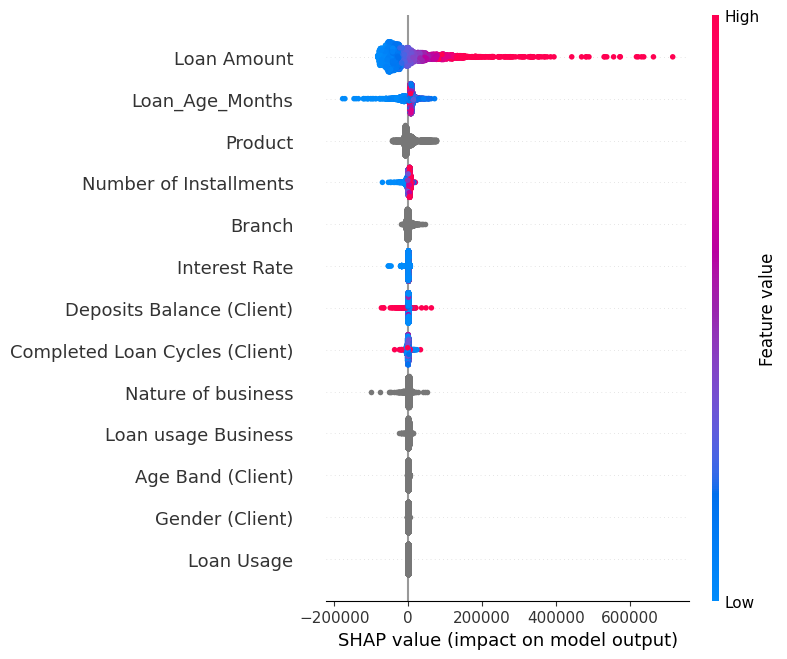

Selected highest-predicted-CLV account index: 3529  predicted realized value rate: 1004080.12


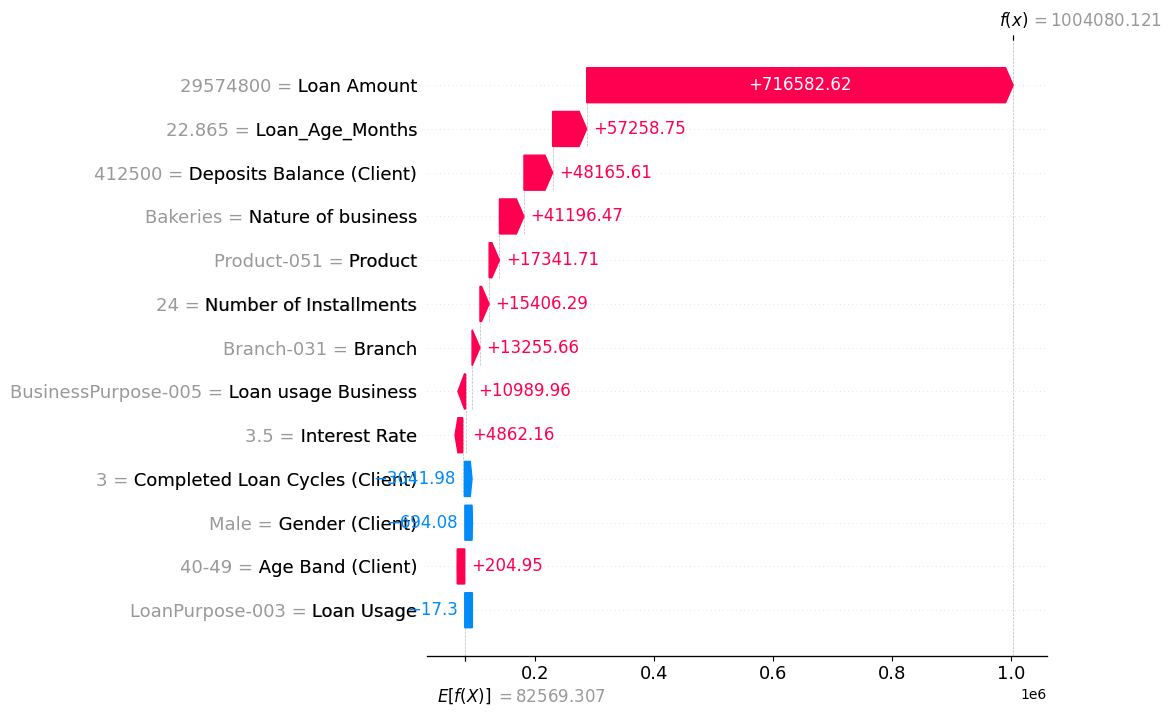

In [437]:
# CLV model (regressor) 
clv_explainer = shap.TreeExplainer(final_model)
clv_shap_values = clv_explainer.shap_values(X_test)

shap.summary_plot(clv_shap_values, X_test, plot_type="bar")
shap.summary_plot(clv_shap_values, X_test)

#Individual client waterfall: the client with the highest predicted CLV 
clv_predictions = final_model.predict(X_test)
selected_position = int(np.argmax(clv_predictions))
selected_index = X_test.index[selected_position]
print("Selected highest-predicted-CLV account index:", selected_index,
      " predicted realized value rate:", round(clv_predictions[selected_position], 2))

clv_feature_cols_list = list(X_test.columns)
individual_shap_clv = pd.DataFrame({
    "Feature": clv_feature_cols_list,
    "SHAP Value": clv_shap_values[selected_position]
})
individual_shap_clv.sort_values("SHAP Value", key=abs, ascending=False)

clv_explanation = shap.Explanation(
    values=clv_shap_values[selected_position],
    base_values=clv_explainer.expected_value,
    data=X_test.iloc[selected_position].values,
    feature_names=clv_feature_cols_list
)
shap.plots.waterfall(clv_explanation, max_display=len(clv_feature_cols_list))

## Saving All Models

In [438]:
import os, json, joblib
from sklearn.preprocessing import StandardScaler

ARTIFACT_DIR = 'artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Component 1 — Financial DNA segmentation
scaler = StandardScaler().fit(seg_data[rfm_cols])
joblib.dump(scaler, f'{ARTIFACT_DIR}/segment_scaler.joblib')
joblib.dump(kmeans, f'{ARTIFACT_DIR}/segment_kmeans.joblib')
joblib.dump(segment_names, f'{ARTIFACT_DIR}/segment_names.joblib')

# Component 2 — Risk / Arrears (uses the risk_* variables frozen in Cell A)
joblib.dump(risk_model, f'{ARTIFACT_DIR}/risk_model.joblib')
joblib.dump({'branch_map': risk_branch_map, 'product_map': risk_product_map,
             'global_arrears_rate': risk_global_arrears_rate},
            f'{ARTIFACT_DIR}/risk_encoders.joblib')

# Component 3 — Customer Lifetime Value
# (feature_cols / categorical_cols here are CLV's — safe, nothing after
# Component 3 reassigns them)
joblib.dump(final_model, f'{ARTIFACT_DIR}/clv_model.joblib')

# Component 4 — Loan Limit Estimation
joblib.dump(limit_model, f'{ARTIFACT_DIR}/limit_model.joblib')

# Component 5 — Fraud Detection (Isolation Forest)
joblib.dump(iso_forest, f'{ARTIFACT_DIR}/fraud_model.joblib')
joblib.dump(anomaly_cols, f'{ARTIFACT_DIR}/fraud_feature_cols.joblib')

# Metadata every downstream consumer (API, SHAP, UI) needs to preprocess a
# new request exactly the way training data was preprocessed
metadata = {
    'cat_features': cat_features,
    'num_features': num_features,
    'risk_feature_cols': risk_feature_cols,
    'limit_num_features': limit_num_features,
    'clv_feature_cols': feature_cols,
    'clv_cat_features': categorical_cols,
    'rfm_cols': rfm_cols,
    'anomaly_cols': anomaly_cols,
    'risk_threshold': risk_threshold,
    'snapshot_date': str(snapshot_date),
}
with open(f'{ARTIFACT_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved:", sorted(os.listdir(ARTIFACT_DIR)))

Saved: ['clv_model.joblib', 'fraud_feature_cols.joblib', 'fraud_model.joblib', 'limit_model.joblib', 'metadata.json', 'risk_encoders.joblib', 'risk_model.joblib', 'segment_kmeans.joblib', 'segment_names.joblib', 'segment_scaler.joblib']
